### Analyze Post-Optimization results for a single run 

**stochastic model with scenario tree for long-term demand uncertainty and using only a subset of weeks each representative year**

# Data reading and setup

In [1]:
# Import python modules
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)

project_root = os.path.abspath(os.path.join(".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
# Now this works because Python sees `src` as a top-level module
from src import analytics, plotting, utils

In [3]:
import yaml

In [4]:
# Notebook input parameters
SAVE_FIGURES = True
SAVE_TABLES = True
show_plots = False
folder_name = "XXX4weeks_1core___"

In [5]:
FOLDER = os.path.join(
    os.path.dirname(os.getcwd()),
    "runs",
    "single_runs",
    folder_name,
)
# FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\37_4week_with_EVPI_and_VSS\1_May05_Mon_h12-GTSEP_stochastic_v1-37_ES_PT"
decision_variables_folder = os.path.join(FOLDER, "decision_variables")
model_info_folder = os.path.join(FOLDER, "model_info")
dual_variables_folder = os.path.join(FOLDER, "dual_variables")

In [6]:
RESULTS_FOLDER = os.path.join(FOLDER, "results")
if not os.path.exists(RESULTS_FOLDER):
    os.makedirs(RESULTS_FOLDER)
if SAVE_TABLES:
    tables_folder = os.path.join(RESULTS_FOLDER, "tables")
    if not os.path.exists(tables_folder):
        os.makedirs(tables_folder)
else:
    tables_folder = None
if SAVE_FIGURES:
    figures_folder = os.path.join(RESULTS_FOLDER, "figures")
    if not os.path.exists(figures_folder):
        os.makedirs(figures_folder)
else:
    figures_folder = None

In [7]:
# Color mapping for scenarios (reuse for other plots)
scenario_colors = {
    "NT": "#1f77b4",
    "GA": "#ff7f0e",
    "DE": "#2ca02c",
    "Average": "#7f7f7f",
}

# Define a consistent color palette for cost categories
category_colors = {
    "Invest Gen": "#b20000",  # dark red
    "Invest Bat": "#0072b2",  # blue
    "Invest Tx": "#009e73",  # green
    "Prod Cost": "#f0e442",  # yellow
    "CO₂ Cost": "#d55e00",  # orange
    "Load Shedding Cost": "#cc79a7",  # magenta
    "Curtailment Cost": "#56b4e9",  # light blue
}

## Read data

In [8]:
model_info = pd.read_csv(os.path.join(model_info_folder, "model_info.csv"))
config = yaml.safe_load(open(os.path.join(model_info_folder, "config.yaml")))
jsons = utils.read_jsons_from_dir(model_info_folder)

In [9]:
scenarios = jsons["scenarios"]
scenario_probabilities = jsons["scenario_probabilities"]
week_weights = jsons["week_weights"]

In [10]:
data_folder_name = config["data_folder_name"]
VOLL = config["VOLL"]
CC = config["CC"]
CO2_price = config["CO2_price"]
E_limit = config["E_limit"]
p_max_new_branch = config["p_max_new_branch"]
p_min_new_branch = config["p_min_new_branch"]
expansion_factor = config["expansion_factor"]
MS = config["MS"]
model_name = config["model_name"]
MIPGap = config["MIPGap"]
years = config["years"]
r = config["discount_rate"]
representative_period_unit = config["representative_period_unit"]
weeks = config["representative_periods"]
scenario_file = config["scenario_file"]

In [11]:
input_data_folder = os.path.join(
    os.path.dirname(os.getcwd()), "data", "processed", config["data_folder_name"]
)
input_data = utils.load_multi_year_csv_files_with_week_from_folder(
    years=years, data_folder_path=input_data_folder
)
scenario_multiplier = utils.load_scenario_multiplier(scenario_file_name=scenario_file)

**Note:** The input data is such that all data is the same for all years. All the data that is year-dependent has year as index. The only exception is the demand data, which does not have copies for years.

In [12]:
dual_variables = utils.load_csv_files_from_folder_with_scenarios(dual_variables_folder)
decision_varables = utils.load_csv_files_from_folder_with_scenarios(
    decision_variables_folder
)

In [13]:
print("Input data")
for data_type in input_data.keys():
    print(f"{data_type}")
print()
print("Decision variables:")
for decision_variable in decision_varables.keys():
    print(decision_variable)
print()
print("Dual variables:")
for dual_variable in dual_variables.keys():
    print(dual_variable)

Input data
batteries
branches
capacity_factors
generators
generator_costs
hourly_demand
nodes

Decision variables:
battery_capacity
battery_charging
battery_discharging
battery_soc
branch_capacity
curtailment
generation
generator_capacity
load_shedding
power_flow

Dual variables:
battery_charge_new_max_duals
battery_charge_old_duals
battery_discharge_new_max_duals
battery_discharge_old_duals
branch_extension_duals
branch_flow_new_duals_max
branch_flow_new_duals_min
branch_flow_old_duals_max
branch_flow_old_duals_min
emissions_duals
gen_extension_duals
gen_output_new_duals
gen_output_old_duals
load_shedding_duals
power_balance_duals


In [14]:
# read dataframes
# input data
batteries = input_data["batteries"]
branches = input_data["branches"]
generators = input_data["generators"]
capacity_factors = input_data["capacity_factors"]
generator_costs = input_data["generator_costs"]
hourly_demand = input_data["hourly_demand"]
nodes = input_data["nodes"]
# decision variables
battery_capacity = decision_varables["battery_capacity"]
battery_charging = decision_varables["battery_charging"]
battery_discharging = decision_varables["battery_discharging"]
battery_soc = decision_varables["battery_soc"]
branch_capacity = decision_varables["branch_capacity"]
curtailment = decision_varables["curtailment"]
generation = decision_varables["generation"]
generator_capacity = decision_varables["generator_capacity"]
load_shedding = decision_varables["load_shedding"]
power_flow = decision_varables["power_flow"]

## Generators analysis

### Generators preprocessing

In [15]:
generators["extension_potential"] = generators["p_nom"] * config["expansion_factor"]

In [16]:
# Example usage:
generators = analytics.add_capacity_and_cumulative_metrics(
    generators, generator_capacity
)

### Generator Investment and Capacity Plots 

In [17]:
if SAVE_FIGURES:
    generators_save_folder = os.path.join(figures_folder, "generators")
    if not os.path.exists(generators_save_folder):
        os.makedirs(generators_save_folder)
else:
    generators_save_folder = None

if SAVE_TABLES:
    generators_save_table_folder = os.path.join(tables_folder, "generators")
    if not os.path.exists(generators_save_table_folder):
        os.makedirs(generators_save_table_folder)
else:
    generators_save_table_folder = None

Annual Capacity Investments by Technology


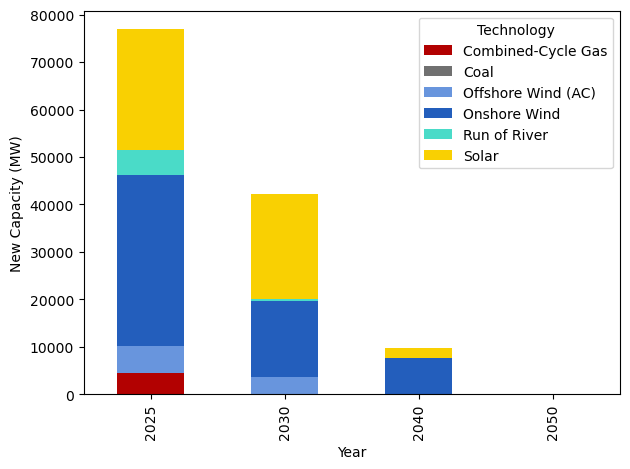

In [18]:
analytics.plot_capacity_investment_by_carrier(generators, generators_save_folder)

Annual Capital Expenditure by Technology


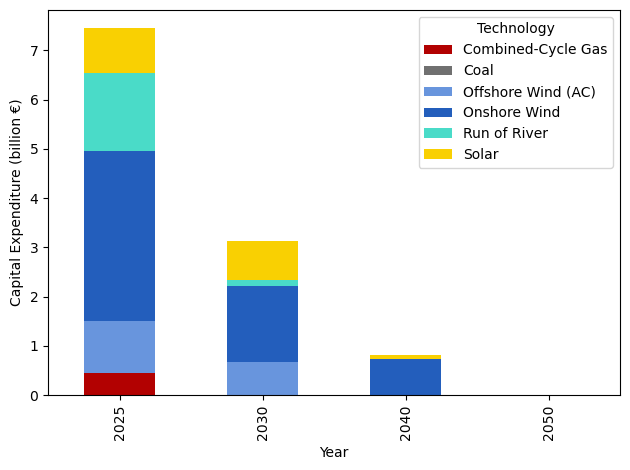

In [19]:
analytics.plot_capacity_spending_by_carrier(generators, generators_save_folder)

Growth in Total Installed Capacity


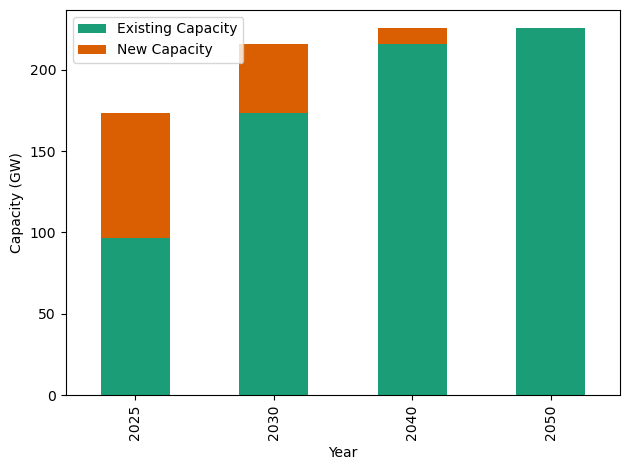

In [20]:
analytics.plot_total_capacity_growth(generators, generators_save_folder)

Extension Potential vs Actual New Capacity by Technology


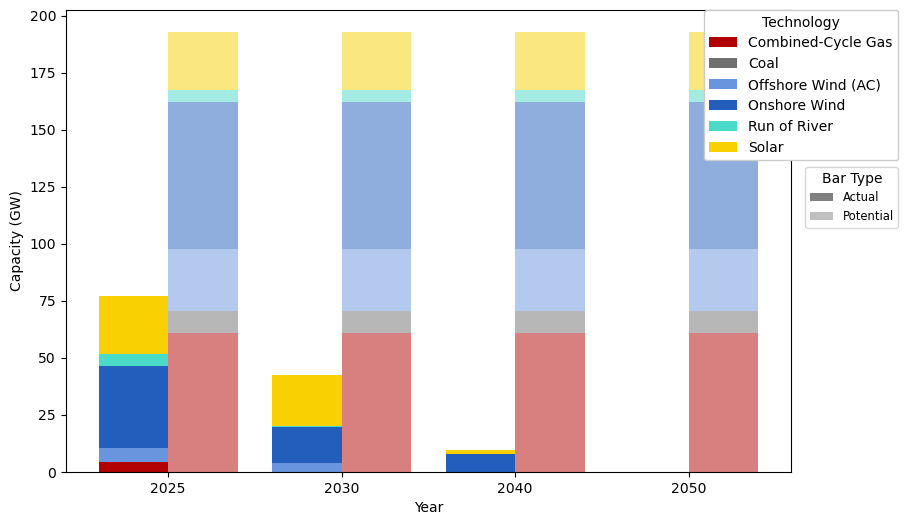

In [21]:
analytics.plot_extension_vs_potential_by_carrier(generators, generators_save_folder)

### Generators Production and Time Series Plots

In [22]:
production_by_carrier_table = analytics.create_energy_production_by_carrier_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights,
    savefolder=generators_save_table_folder,
)
production_by_carrier_table


Annual expected energy production by carrier (scenario-weighted):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar
year,,,,,,
2025,4.612881e+07,1.332259e+06,3.582265e+07,1.030797e+08,3.739784e+07,5.152404e+07
2030,3.157218e+07,1.424320e+06,3.651292e+07,1.086381e+08,3.938636e+07,7.788148e+07
2040,4.504883e+07,2.713651e+06,4.197947e+07,1.388627e+08,3.938636e+07,8.426533e+07
2050,5.139102e+07,3.281600e+06,4.468682e+07,1.510595e+08,3.938636e+07,8.528472e+07


In [23]:
annual_production_table = analytics.make_annual_production_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights=week_weights,
    savefolder=generators_save_table_folder,
)
annual_production_table

Annual expected energy production by carrier and scenario (MWh):


carrier                CCGT          coal    offwind-ac        onwind  \
year scenario                                                           
2025 NT        4.612881e+07  1.332259e+06  3.582265e+07  1.030797e+08   
2030 NT        3.157218e+07  1.424320e+06  3.651292e+07  1.086381e+08   
2040 DE        1.714871e+07  1.046903e+06  1.474290e+07  4.853912e+07   
     GA        1.197039e+07  6.839964e+05  1.295134e+07  4.286196e+07   
     NT        1.592973e+07  9.827521e+05  1.428523e+07  4.746158e+07   
2050 DE        3.074222e+07  1.907920e+06  2.335425e+07  8.033839e+07   
     GA        2.064880e+07  1.373680e+06  2.133257e+07  7.072115e+07   

carrier                 ror         solar         Total  
year scenario                                            
2025 NT        3.739784e+07  5.152404e+07  2.752853e+08  
2030 NT        3.938636e+07  7.788148e+07  2.954154e+08  
2040 DE        1.312879e+07  2.829657e+07  1.229030e+08  
     GA        1.312879e+07  2.774942e+07  1.093459e+08  
     NT        1.312879e+07  2.821934e+07  1.200074e+08  
2050 DE        1.969318e+07  4.274169e+07  1.987776e+08  
     GA        1.969318e+07  4.254303e+07  1.763124e+08

In [24]:
annual_cost_table = analytics.make_weighted_annual_production_cost_by_year_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights,
    carbon_price=CO2_price,
    savefolder=generators_save_table_folder,
)
annual_cost_table

Annual scenario-weighted production cost (incl. CO₂) by technology (EUR):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar,Total
year,,,,,,,
2025,2.579421e+09,7.606796e+07,537339.736947,1.546195e+06,0.0,515240.385653,2.658087e+09
2030,1.766468e+09,8.132434e+07,547693.751842,1.629572e+06,0.0,778814.823618,1.850748e+09
2040,2.527882e+09,1.549413e+08,629692.020049,2.082940e+06,0.0,842653.300191,2.686379e+09
2050,2.884687e+09,1.873694e+08,670302.366089,2.265893e+06,0.0,852847.218959,3.075846e+09


In [25]:
weighted_annual_production_by_year = analytics.make_weighted_annual_production_by_year(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights=week_weights,
    savefolder=generators_save_table_folder,
)
weighted_annual_production_by_year

Annual scenario-weighted energy production by carrier (MWh):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar,Total
year,,,,,,,
2025,4.612881e+07,1.332259e+06,3.582265e+07,1.030797e+08,3.739784e+07,5.152404e+07,2.752853e+08
2030,3.157218e+07,1.424320e+06,3.651292e+07,1.086381e+08,3.938636e+07,7.788148e+07,2.954154e+08
2040,4.504883e+07,2.713651e+06,4.197947e+07,1.388627e+08,3.938636e+07,8.426533e+07,3.522563e+08
2050,5.139102e+07,3.281600e+06,4.468682e+07,1.510595e+08,3.938636e+07,8.528472e+07,3.750901e+08


Evolution of Annual Energy Production by Technology (averaged across scenarios)


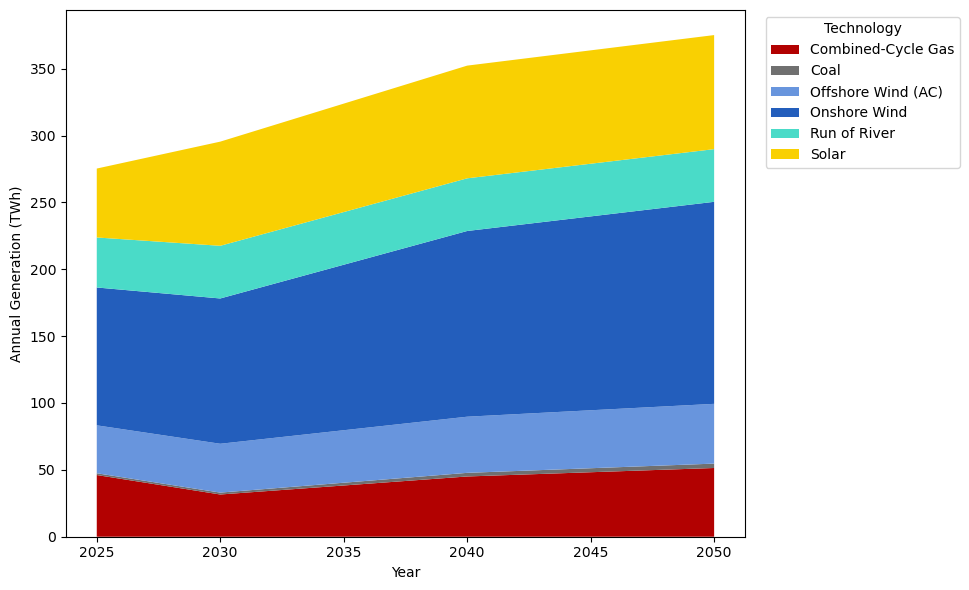

In [26]:
analytics.plot_weighted_production_evolution(
    weighted_annual_production_by_year, generators, savefolder=generators_save_folder
)

Evolution of Annual Production Cost including CO₂ Emissions by Technology


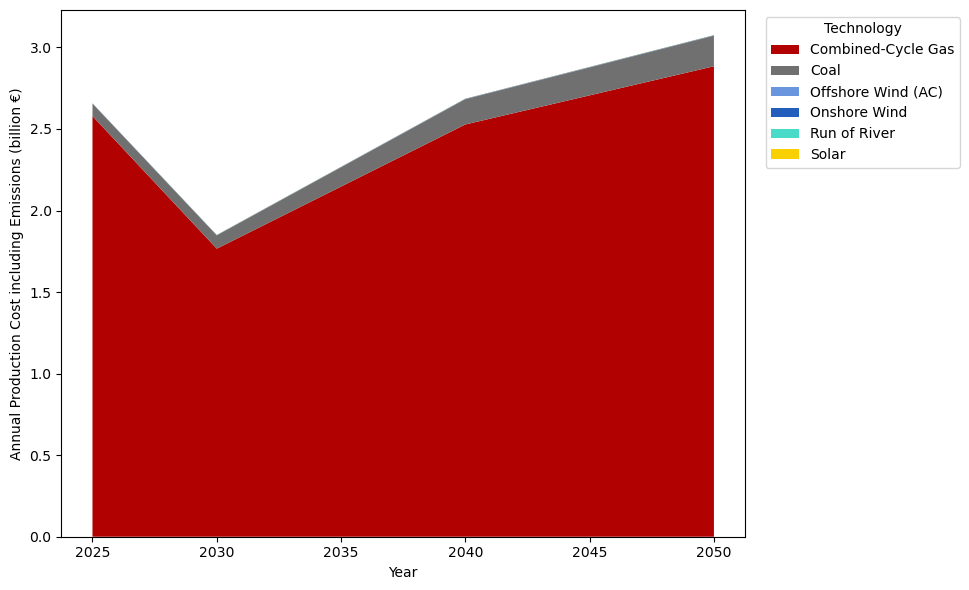

In [27]:
analytics.plot_weighted_production_cost_evolution(
    annual_cost_table, generators, savefolder=generators_save_folder
)

In [28]:
yearly_system_cost_table = analytics.make_yearly_system_costs_table(
    generation, generators, week_weights, CO2_price, generators_save_table_folder
)
yearly_system_cost_table

Yearly system metrics by year and scenario:


production  co2_emission  co2_emission_cost  production_cost  \
year scenario                                                                   
2025 NT        2.752853e+08  9.678730e+06       8.226920e+08     1.835395e+09   
2030 NT        2.954154e+08  6.798705e+06       5.778899e+08     1.272858e+09   
2040 DE        3.687090e+08  1.135707e+07       9.653506e+08     2.107953e+09   
     GA        3.280376e+08  7.879909e+06       6.697923e+08     1.461924e+09   
     NT        3.600223e+08  1.056025e+07       8.976211e+08     1.956496e+09   
2050 DE        3.975553e+08  1.359427e+07       1.155513e+09     2.521499e+09   
     GA        3.526248e+08  9.193624e+06       7.814581e+08     1.693221e+09   

               production_cost_with_emission  
year scenario                                 
2025 NT                         2.658087e+09  
2030 NT                         1.850748e+09  
2040 DE                         3.073303e+09  
     GA                         2.131717e+09  
     NT                         2.854117e+09  
2050 DE                         3.677012e+09  
     GA                         2.474679e+09

CO₂ Emissions by Year and Scenario


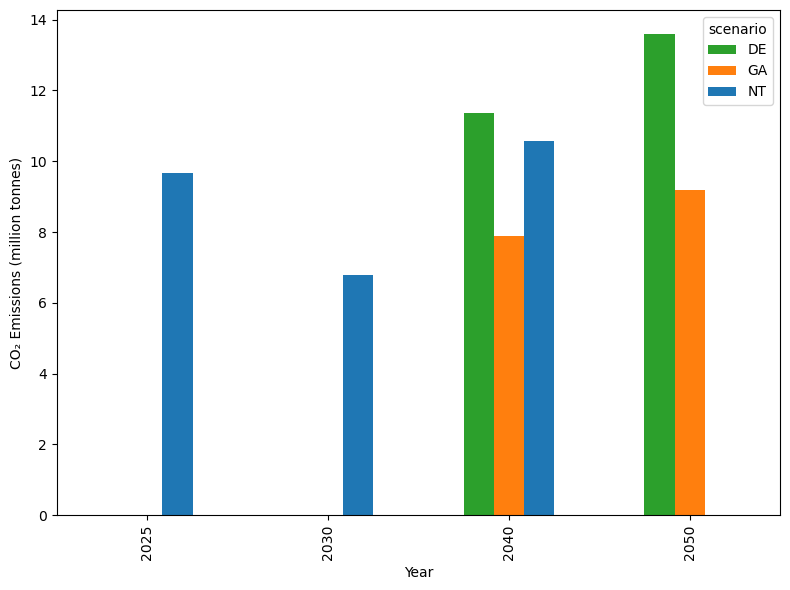

CO₂ Emissions by Year, Scenario, and Average


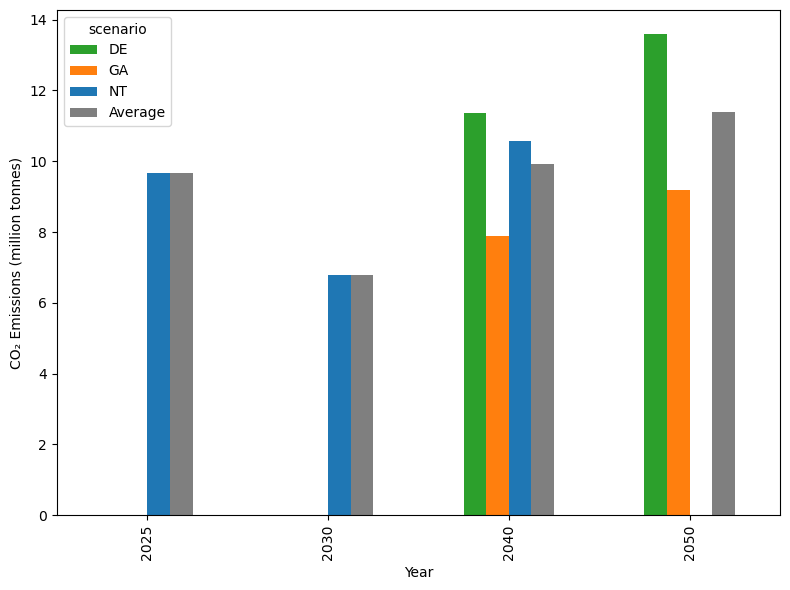

Annual Production by Year, Scenario, and Average


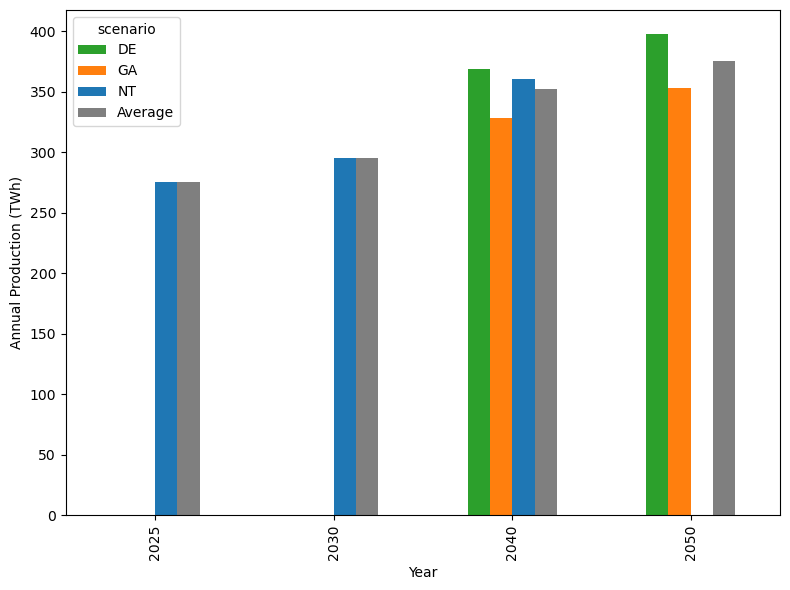

Production Cost by Year, Scenario, and Average


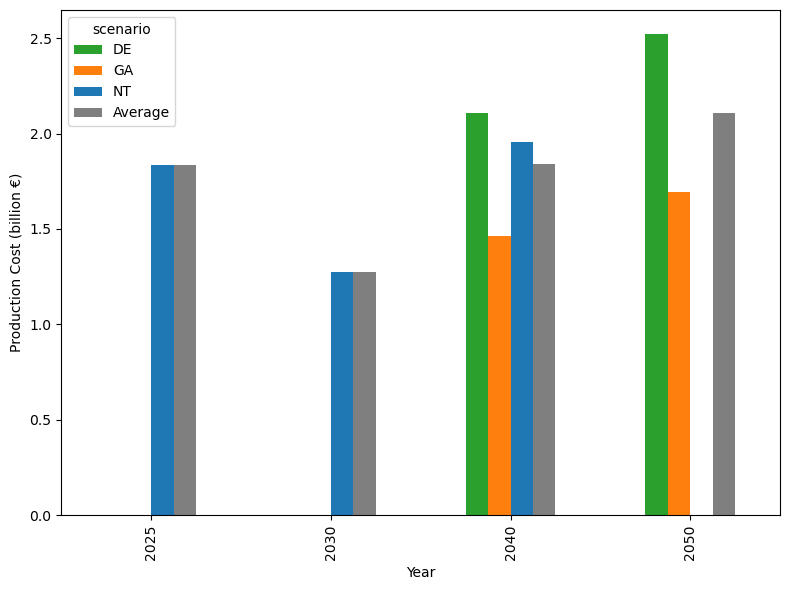

Production Cost w/ Emissions by Year, Scenario, and Average


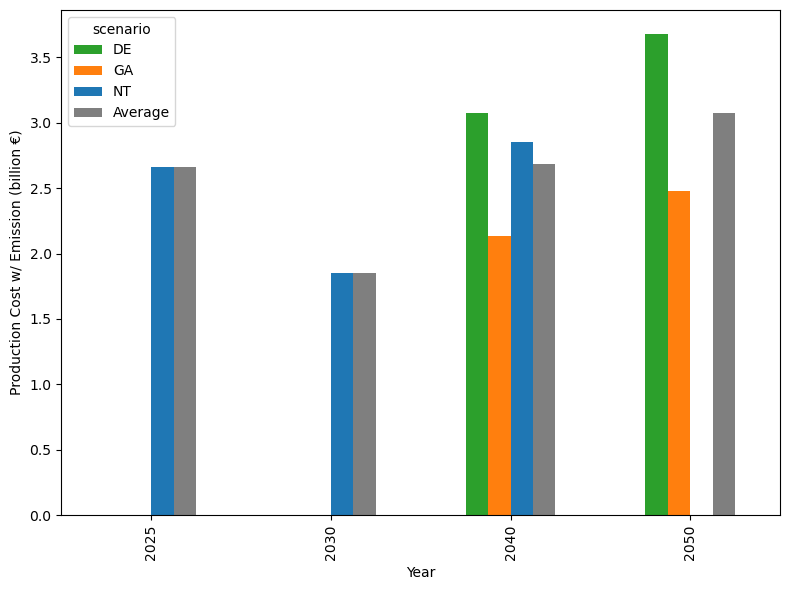

In [29]:
analytics.plot_co2_emissions_by_scenario(
    yearly_system_cost_table, savefolder=generators_save_folder
)
analytics.plot_co2_emissions_by_scenario_avg(
    yearly_system_cost_table, generators_save_folder
)
analytics.plot_production_by_scenario(yearly_system_cost_table, generators_save_folder)
analytics.plot_production_cost_by_scenario(
    yearly_system_cost_table, generators_save_folder
)
analytics.plot_production_cost_with_emission_by_scenario(
    yearly_system_cost_table, generators_save_folder
)

In [30]:
# if figures_folder:
#     generation_curves_folder = os.path.join(figures_folder, "generation_curves")
#     os.makedirs(generation_curves_folder, exist_ok=True)
# else:
#     generation_curves_folder = None

# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# carriers = generators.reset_index()["carrier"].unique()

# for year in years:
#     for scen in scenarios[str(year)]:
#         for week in weeks:
#             for carrier in carriers:
#                 analytics.plot_fraction_of_max_generation_by_carrier(
#                     generation,
#                     capacity_factors,
#                     generators,
#                     year,
#                     week,
#                     scen,
#                     carrier,
#                     savefolder=generation_curves_folder,  # or None if you don’t want to save
#                 )

In [31]:
# # loop over combinations
# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# for year in years:
#     for scen in scenarios[str(year)]:
#         for week in weeks:
#             analytics.plot_utilization_time_series_by_carrier(
#                 generation,
#                 capacity_factors,
#                 generators,
#                 year,
#                 week,
#                 scen,
#                 savefolder=tables_folder,
#             )

Annual Utilization Factor by Year, Scenario, and Carrier


c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:2420: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  actual_car = actual.groupby(gen2car, axis=1).sum()  # (year,scenario)×carrier
c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:2421: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  potential_car = potential.groupby(gen2car, axis=1).sum()  # year×carrier


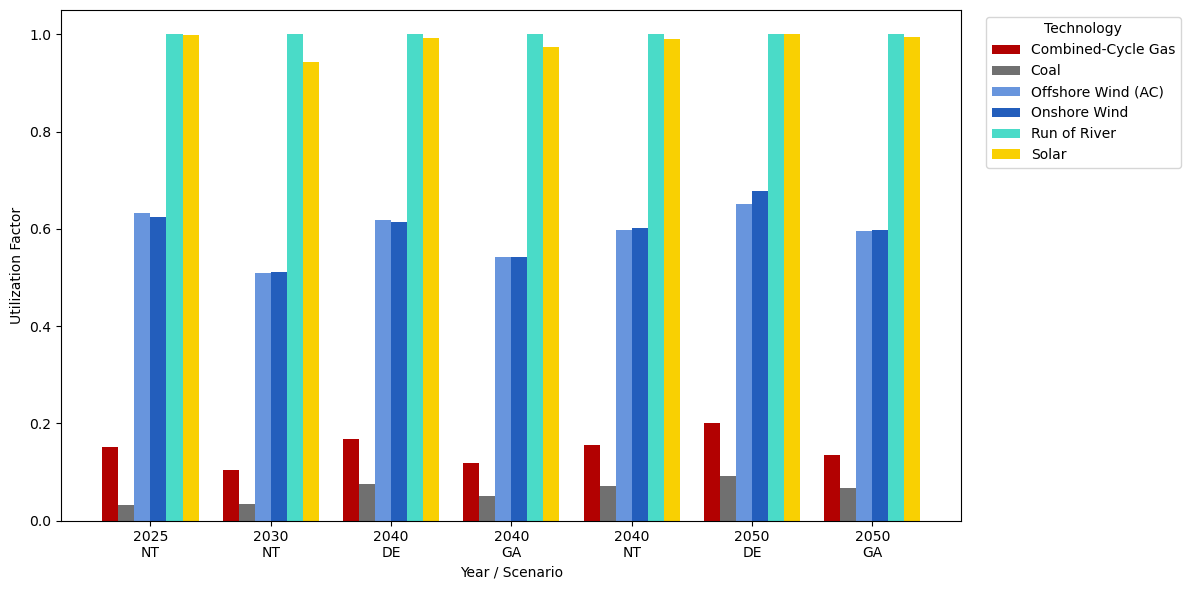

In [32]:
analytics.plot_utilization_hierarchy(
    generation,
    capacity_factors,
    generators,
    week_weights,
    scenarios,
    savefolder=generators_save_folder,
)

In [33]:
summary_table = analytics.make_system_summary_table(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    savefolder=tables_folder,
)

In [34]:
summary_table

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout,total_production,total_co2_emissions,total_co2_emission_cost,total_production_cost,total_production_cost_with_emission,total_cost
year,,,,,,,,,,,
2025,192912.81714,76972.204833,51,22,7.447474e+09,2.752853e+08,9.678730e+06,8.226920e+08,1.835395e+09,2.658087e+09,1.010556e+10
2030,192912.81714,42286.805568,51,14,3.126891e+09,2.954154e+08,6.798705e+06,5.778899e+08,1.272858e+09,1.850748e+09,4.977639e+09
2040,192912.81714,9685.035458,51,2,8.084783e+08,3.522563e+08,9.932408e+06,8.442546e+08,1.842124e+09,2.686379e+09,3.494857e+09
2050,192912.81714,0.000000,51,0,0.000000e+00,3.750901e+08,1.139395e+07,9.684856e+08,2.107360e+09,3.075846e+09,3.075846e+09


In [35]:
summary_by_carrier_table = analytics.make_system_summary_table_by_carrier(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    tables_folder,
)
summary_by_carrier_table

potential_capacity  new_capacity  number_possible_buildouts  \
year carrier                                                                   
2025 CCGT              60900.664000   4464.906949                         11   
     coal               9478.786965      0.000000                          5   
     offwind-ac        27469.304444   5750.206760                          9   
     onwind            64079.006689  36066.052577                         11   
     ror                5571.016495   5277.000000                          4   
     solar             25414.038546  25414.038546                         11   
2030 CCGT              60900.664000      0.000000                         11   
     coal               9478.786965      0.000000                          5   
     offwind-ac        27469.304444   3638.183698                          9   
     onwind            64079.006689  16021.999255                         11   
     ror                5571.016495    426.070288                          4   
     solar             25414.038546  22200.552327                         11   
2040 CCGT              60900.664000      0.000000                         11   
     coal               9478.786965      0.000000                          5   
     offwind-ac        27469.304444      0.000000                          9   
     onwind            64079.006689   7666.034392                         11   
     ror                5571.016495      0.000000                          4   
     solar             25414.038546   2019.001067                         11   
2050 CCGT              60900.664000      0.000000                         11   
     coal               9478.786965      0.000000                          5   
     offwind-ac        27469.304444      0.000000                          9   
     onwind            64079.006689      0.000000                         11   
     ror                5571.016495      0.000000                          4   
     solar             25414.038546      0.000000                         11   

                 number_actual_buildouts  cost_of_buildout  total_production  \
year carrier                                                                   
2025 CCGT                              1      4.421496e+08      4.612881e+07   
     coal                              0      0.000000e+00      1.332259e+06   
     offwind-ac                        2      1.056531e+09      3.582265e+07   
     onwind                            6      3.465439e+09      1.030797e+08   
     ror                               2      1.578563e+09      3.739784e+07   
     solar                            11      9.047924e+08      5.152404e+07   
2030 CCGT                              0      0.000000e+00      3.157218e+07   
     coal                              0      0.000000e+00      1.424320e+06   
     offwind-ac                        1      6.695623e+08      3.651292e+07   
     onwind                            2      1.539488e+09      1.086381e+08   
     ror                               1      1.274548e+08      3.938636e+07   
     solar                            10      7.903856e+08      7.788148e+07   
2040 CCGT                              0      0.000000e+00      4.504883e+07   
     coal                              0      0.000000e+00      2.713651e+06   
     offwind-ac                        0      0.000000e+00      4.197947e+07   
     onwind                            1      7.365977e+08      1.388627e+08   
     ror                               0      0.000000e+00      3.938636e+07   
     solar                             1      7.188062e+07      8.426533e+07   
2050 CCGT                              0      0.000000e+00      5.139102e+07   
     coal                              0      0.000000e+00      3.281600e+06   
     offwind-ac                        0      0.000000e+00      4.468682e+07   
     onwind                            0      0.000000e+00      1.510595e+08   
     ror        

## Transmission Lines

In [36]:
# Preprocessing
if "extended_by" in branches.columns:
    branches.drop(columns=["extended_by"], inplace=True)
if "branch" in branch_capacity.index.names:
    branch_capacity = branch_capacity.rename_axis(index={"branch": "line"})
if "branch" in power_flow.index.names:
    power_flow = power_flow.rename_axis(index={"branch": "line"})
branches["extension_potential"] = p_max_new_branch

In [37]:
if SAVE_FIGURES:
    branches_save_folder = os.path.join(figures_folder, "branches")
    if not os.path.exists(branches_save_folder):
        os.makedirs(branches_save_folder)
else:
    branches_save_folder = None
if SAVE_TABLES:
    branches_save_table_folder = os.path.join(tables_folder, "branches")
    if not os.path.exists(branches_save_table_folder):
        os.makedirs(branches_save_table_folder)
else:
    branches_save_table_folder = None

In [38]:
branches = analytics.extend_branches_table(branches, branch_capacity)

Annual New Branch Capacity Additions


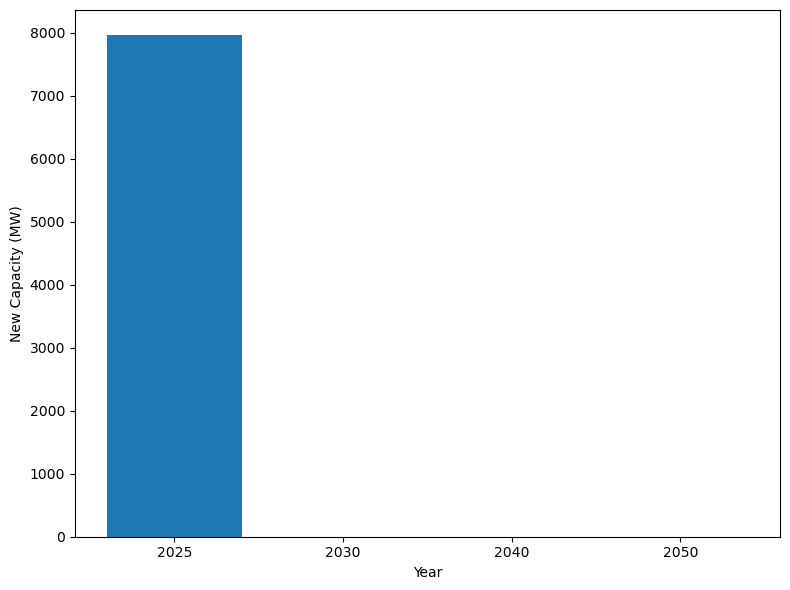

In [39]:
analytics.plot_branch_new_capacity(branches, savefolder=branches_save_folder)

In [40]:
branch_buildout_summary = analytics.make_branch_buildout_summary(
    branches, savefolder=branches_save_table_folder
)


branch_buildout_summary

Branch buildout summary by year:


,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout
year,,,,,
2025,95000,7964.494407,19,2,1.341461e+08
2030,95000,0.000000,19,0,0.000000e+00
2040,95000,0.000000,19,0,0.000000e+00
2050,95000,0.000000,19,0,0.000000e+00


In [41]:
branch_flow_table_per_line = analytics.make_branch_flow_metrics(
    power_flow, branches, week_weights, savefolder=branches_save_table_folder
)
branch_flow_table_per_line

utilization_rate  congestion_rate
line scenario year                                   
88   DE       2040          0.996223         0.971726
              2050          0.994858         0.967262
     GA       2040          0.998829         0.989583
              2050          0.996546         0.974702
     NT       2025          0.998898         0.988095
...                              ...              ...
219  GA       2040          0.608814         0.081845
              2050          0.618406         0.080357
     NT       2025          0.661940         0.078869
              2030          0.606082         0.049107
              2040          0.628735         0.092262

[133 rows x 2 columns]

In [42]:
branch_flow_summary = analytics.make_aggregate_branch_flow_summary(
    power_flow, branches, week_weights, savefolder=branches_save_table_folder
)
branch_flow_summary

utilization_rate  congestion_rate
year scenario                                   
2025 NT                0.619219         0.506422
2030 NT                0.626184         0.508772
2040 DE                0.638244         0.513863
     GA                0.632837         0.514019
     NT                0.637183         0.514489
2050 DE                0.644693         0.516996
     GA                0.635959         0.511670

Transmission line investments in 2025:


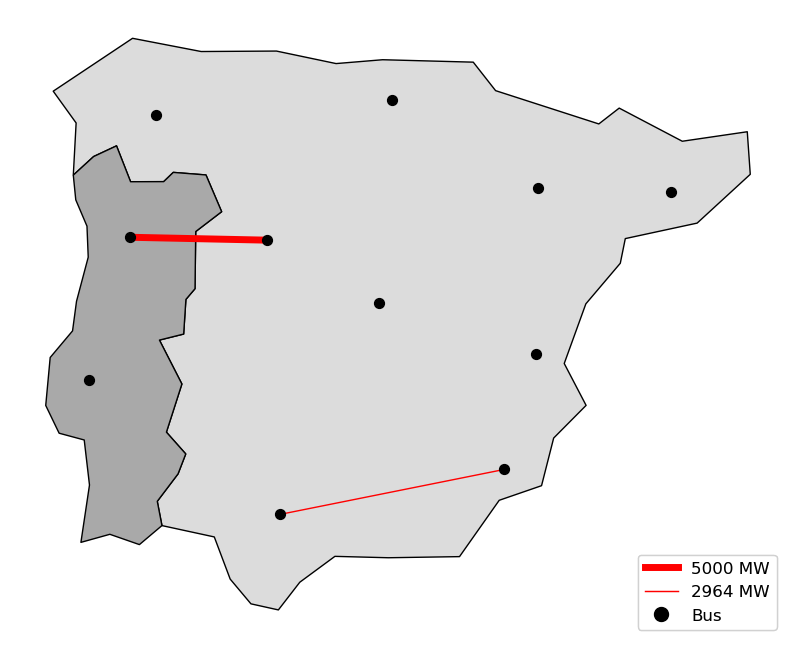

Plotting grid with new branches in year 2025


In [43]:
analytics.plot_new_branches_for_years_with_investments(
    branches, branch_capacity, nodes, savefolder=branches_save_folder
)

## Batteries

In [44]:
if SAVE_FIGURES:
    batteries_save_folder = os.path.join(figures_folder, "batteries")
    if not os.path.exists(batteries_save_folder):
        os.makedirs(batteries_save_folder)
else:
    batteries_save_folder = None
if SAVE_TABLES:
    batteries_save_table_folder = os.path.join(tables_folder, "batteries")
    if not os.path.exists(batteries_save_table_folder):
        os.makedirs(batteries_save_table_folder)
    else:
        batteries_save_table_folder = None

Annual Battery Capacity Investments


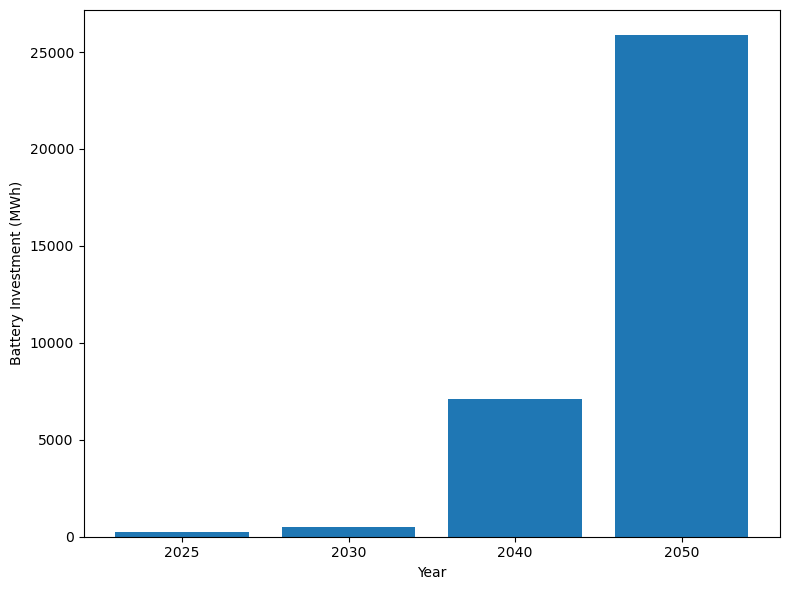

Annual Battery Investment Cost (million €)


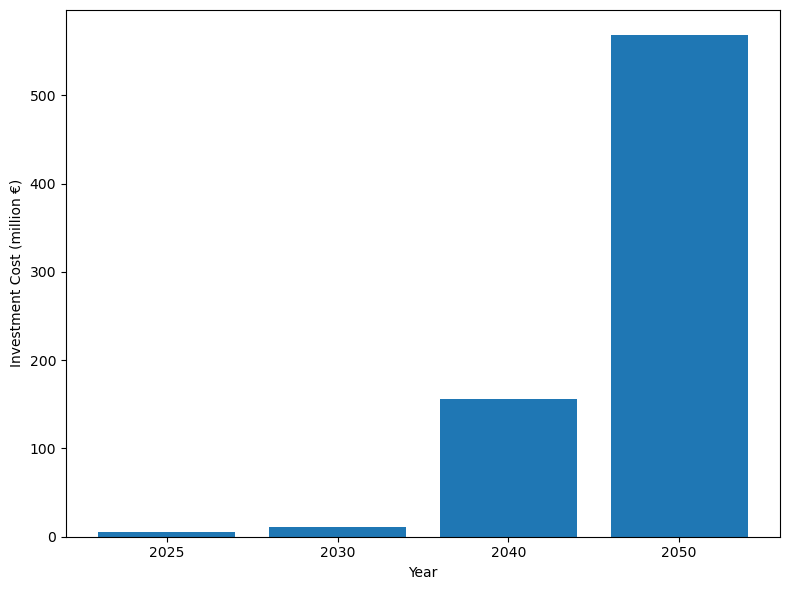

Number of 320 MWh Cycles by Year, Scenario, and Average


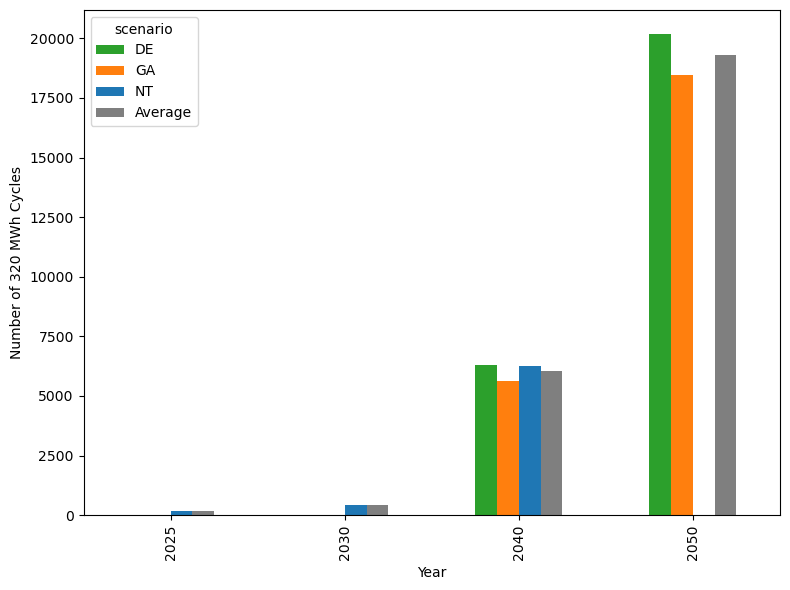

In [45]:
if len(batteries) > 0:
    batteries = analytics.extend_batteries_table(batteries.copy(), battery_capacity)
    analytics.plot_battery_investment_by_year(
        batteries, savefolder=batteries_save_folder
    )
    analytics.plot_battery_investment_cost_by_year(
        batteries, savefolder=batteries_save_folder
    )
    battery_summary = analytics.make_battery_system_summary(
        batteries,
        battery_discharging,
        week_weights,
        scenarios,
        scenario_probabilities,
        batteries_save_table_folder,
    )
    analytics.plot_cycles_per_scenario_with_average(
        battery_discharging,
        week_weights,
        reference_cycle_mwh=400 * (0.8),
        savefolder=batteries_save_folder,
    )
    battery_summary

Annual Curtailment by Year and Scenario


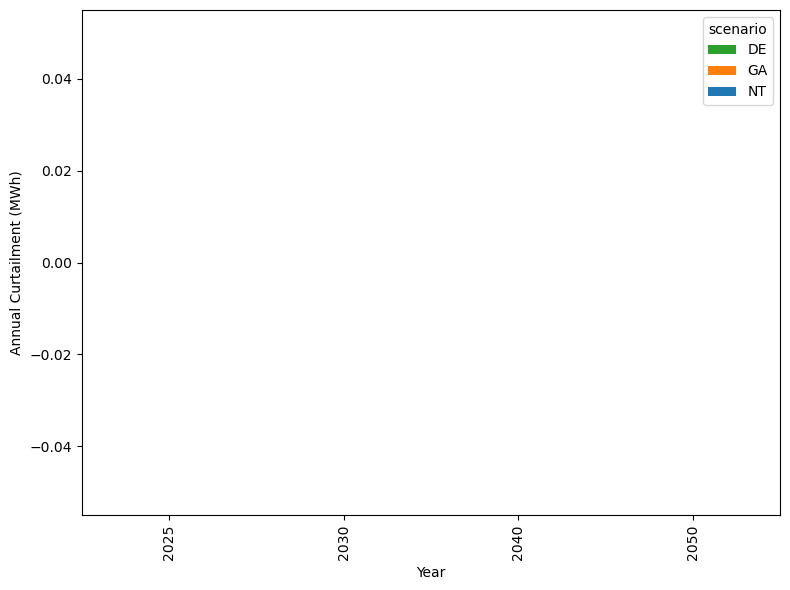

Annual Load Shedding by Year and Scenario


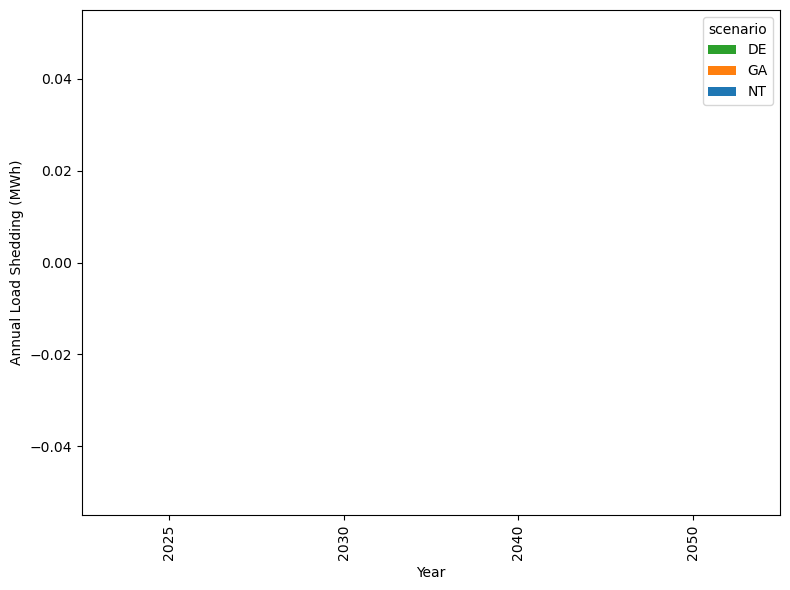

In [46]:
analytics.plot_curtailment_by_scenario(
    curtailment, week_weights, savefolder=figures_folder
)


analytics.plot_load_shedding_by_scenario(
    load_shedding, week_weights, savefolder=figures_folder
)

In [47]:
curtailment_and_load_shedding_table = (
    analytics.make_curtailment_load_shedding_cost_table(
        curtailment, load_shedding, week_weights, CC, VOLL, savefolder=tables_folder
    )
)
curtailment_and_load_shedding_table

load_shedding  curtailment  load_shedding_cost  \
year scenario                                                   
2025 NT                  0.0          0.0                 0.0   
2030 NT                  0.0          0.0                 0.0   
2040 DE                  0.0          0.0                 0.0   
     GA                  0.0          0.0                 0.0   
     NT                  0.0          0.0                 0.0   
2050 DE                  0.0          0.0                 0.0   
     GA                  0.0          0.0                 0.0   

               curtailment_cost  
year scenario                    
2025 NT                     0.0  
2030 NT                     0.0  
2040 DE                     0.0  
     GA                     0.0  
     NT                     0.0  
2050 DE                     0.0  
     GA                     0.0

## Macro analysis

In [48]:
if SAVE_FIGURES:
    macro_save_folder = os.path.join(figures_folder, "macro")
    if not os.path.exists(macro_save_folder):
        os.makedirs(macro_save_folder)
else:
    macro_save_folder = None
if SAVE_TABLES:
    macro_save_table_folder = os.path.join(tables_folder, "macro")
    if not os.path.exists(macro_save_table_folder):
        os.makedirs(macro_save_table_folder)
else:
    macro_save_table_folder = None

In [49]:
system_summary = analytics.make_system_summary_table(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    savefolder=macro_save_folder,
)

In [50]:
if len(batteries) > 0:
    battery_summary = analytics.make_battery_system_summary(
        batteries,
        battery_discharging,
        week_weights,
        scenarios,
        scenario_probabilities,
        savefolder=tables_folder,
    )
else:
    # Dummy columns
    columns = ["num_buildout", "capacity", "investment_cost", "cycles_per_year"]

    # Create the DataFrame with NaNs
    empty_df = pd.DataFrame(index=years, columns=columns)
    empty_df.index.name = "year"
    battery_summary = empty_df

In [51]:
branch_summary = analytics.make_branch_buildout_summary(branches, tables_folder)
yearly_system_cost_table = analytics.make_yearly_system_costs_table(
    generation, generators, week_weights, CO2_price, savefolder=tables_folder
)
curtailment_and_load_shedding_table = (
    analytics.make_curtailment_load_shedding_cost_table(
        curtailment, load_shedding, week_weights, CC, VOLL, savefolder=tables_folder
    )
)

Branch buildout summary by year:
Yearly system metrics by year and scenario:


Annual System Costs (average across scenarios)


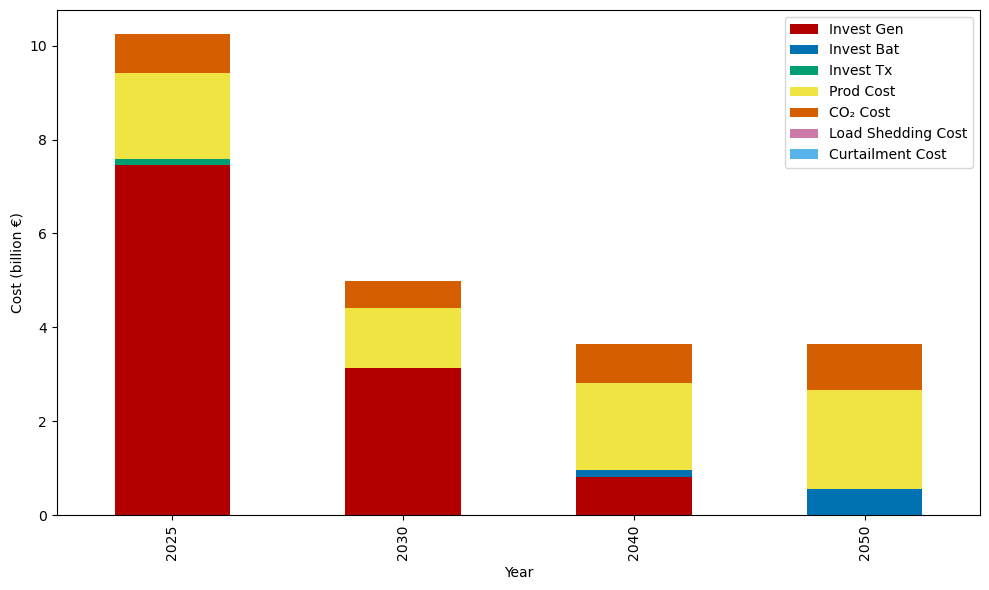

Annual System Costs by Scenario


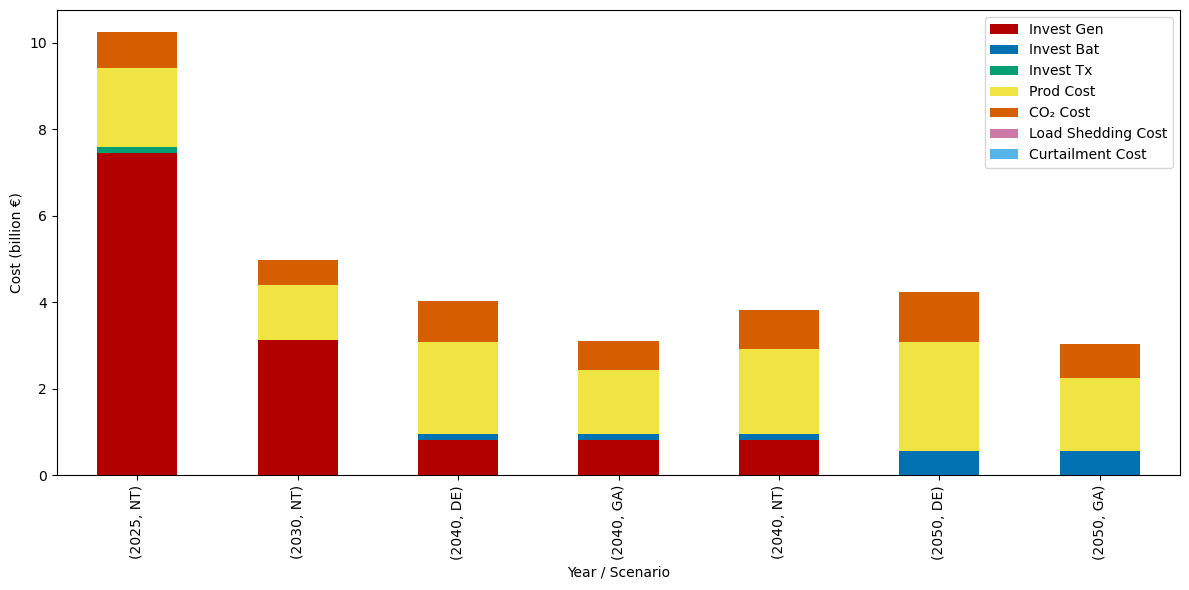

In [52]:
analytics.plot_yearly_costs_stacked_avg(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    savefolder=macro_save_folder,
)
analytics.plot_yearly_costs_stacked_by_scenario(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    savefolder=macro_save_folder,
)

In [53]:
total_system_cost = analytics.compute_total_system_cost(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    scenarios,
    scenario_probabilities,
    savefolder=macro_save_table_folder,
)
total_system_cost

Total system cost by year:


,AIC,expected_OC,total_cost
year,,,
2025,7.587396e+09,2.658087e+09,1.024548e+10
2030,3.137353e+09,1.850748e+09,4.988101e+09
2040,9.641585e+08,2.686379e+09,3.650537e+09
2050,5.681559e+08,3.075846e+09,3.644001e+09


In [54]:
assert (
    abs(total_system_cost["total_cost"].sum() - model_info["Objective Value"][0]) < 1000
), f"Mismatch in total system cost: {total_system_cost['total_cost'].sum():,.0f} vs {model_info['Objective Value'][0]:,.0f}"

In [55]:
mega_table = analytics.make_mega_cost_table(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    scenarios,
    scenario_probabilities,
    savefolder=macro_save_table_folder,
)
mega_table

Invest Gen    Invest Bat     Invest Tx  Production Cost  \
year scenario                                                              
2025 NT        7.447474e+09  5.775301e+06  1.341461e+08     1.835395e+09   
2030 NT        3.126891e+09  1.046250e+07  0.000000e+00     1.272858e+09   
2040 DE        8.084783e+08  1.556802e+08  0.000000e+00     2.107953e+09   
     GA        8.084783e+08  1.556802e+08  0.000000e+00     1.461924e+09   
     NT        8.084783e+08  1.556802e+08  0.000000e+00     1.956496e+09   
2050 DE        0.000000e+00  5.681559e+08  0.000000e+00     2.521499e+09   
     GA        0.000000e+00  5.681559e+08  0.000000e+00     1.693221e+09   
All  All       1.138284e+10  7.400739e+08  1.341461e+08     7.057738e+09   

               CO2 Emission Cost  Load Shedding Cost  Curtailment Cost  \
year scenario                                                            
2025 NT             8.226920e+08                 0.0               0.0   
2030 NT             5.778899e+08                 0.0               0.0   
2040 DE             9.653506e+08                 0.0               0.0   
     GA             6.697923e+08                 0.0               0.0   
     NT             8.976211e+08                 0.0               0.0   
2050 DE             1.155513e+09                 0.0               0.0   
     GA             7.814581e+08                 0.0               0.0   
All  All            3.213322e+09                 0.0               0.0   

               Prod+CO2 Cost   Total CapEx    Total OpEx    Total Cost  
year scenario                                                           
2025 NT         2.658087e+09  7.587396e+09  2.658087e+09  1.024548e+10  
2030 NT         1.850748e+09  3.137353e+09  1.850748e+09  4.988101e+09  
2040 DE         3.073303e+09  9.641585e+08  3.073303e+09  4.037462e+09  
     GA         2.131717e+09  9.641585e+08  2.131717e+09  3.095875e+09  
     NT         2.854117e+09  9.641585e+08  2.854117e+09  3.818275e+09  
2050 DE         3.677012e+09  5.681559e+08  3.677012e+09  4.245168e+09  
     GA         2.474679e+09  5.681559e+08  2.474679e+09  3.042835e+09  
All  All        1.027106e+10  1.225706e+10  1.027106e+10  2.252812e+10

In [56]:
# End  by saving the extended generators, transmission lines, and batteries tables to and extended tables folder
if tables_folder:
    # Create the extended tables folder if it doesn't exist
    extended_tables_folder = os.path.join(tables_folder, "extended_tables")
    os.makedirs(extended_tables_folder, exist_ok=True)
    generators.to_csv(
        os.path.join(extended_tables_folder, "extended_generators.csv"), index=False
    )
    branches.to_csv(
        os.path.join(extended_tables_folder, "extended_branches.csv"), index=False
    )
    batteries.to_csv(
        os.path.join(extended_tables_folder, "extended_batteries.csv"), index=False
    )

# Dual Variables Analysis

In [57]:
for key, df in dual_variables.items():
    print(key)
    print()
    display(df.head(2))
    print("------------------------")

battery_charge_new_max_duals



dual_value
battery   scenario year week hour            
ES1 0 bat NT       2025 11   0            0.0
                             1            0.0

------------------------
battery_charge_old_duals



,,,,,,dual_value
battery,bound,scenario,year,week,hour,


------------------------
battery_discharge_new_max_duals



...

------------------------
load_shedding_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0            0.0
                         1            0.0

------------------------
power_balance_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0        0.01505
                         1        0.01500

------------------------


In [58]:
# Build a DataFrame of scenario probabilities (p_{ω,y})
prob_rows = []
for year_str, scen_list in scenarios.items():
    year = int(year_str)
    probs = scenario_probabilities[year_str]
    for scen, p in zip(scen_list, probs):
        prob_rows.append({"year": year, "scenario": scen, "p": p})
prob_df = pd.DataFrame(prob_rows).set_index(["year", "scenario"])

prob_df

p
year scenario          
2025 NT        1.000000
2030 NT        1.000000
2040 NT        0.333333
     GA        0.333333
     DE        0.333333
2050 GA        0.500000
     DE        0.500000

In [59]:
# Loop through duals and apply 1/p weighting where appropriate
for key, df in dual_variables.items():
    print(key)
    print()
    display(df.head(2))

    # Only apply to duals that vary by scenario
    if "scenario" in df.index.names:
        temp = df.reset_index().merge(prob_df, on=["year", "scenario"], how="left")
        # Compute 1/p weight
        temp["weight"] = 1.0 / temp["p"]
        # Apply weight to the dual values
        temp["dual_value"] = temp["dual_value"] * temp["weight"]

        # Reconstruct a weighted-dual Series with the original index
        weighted = temp.set_index(df.index.names)
        # Display the first two rows
        display(weighted.head(2))
        dual_variables[key] = weighted

battery_charge_new_max_duals



dual_value
battery   scenario year week hour            
ES1 0 bat NT       2025 11   0            0.0
                             1            0.0

dual_value    p  weight
battery   scenario year week hour                         
ES1 0 bat NT       2025 11   0            0.0  1.0     1.0
                             1            0.0  1.0     1.0

battery_charge_old_duals



,,,,,,dual_value
battery,bound,scenario,year,week,hour,


...

dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0            0.0
                         1            0.0

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 11   0            0.0  1.0     1.0
                         1            0.0  1.0     1.0

power_balance_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0        0.01505
                         1        0.01500

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 11   0        0.01505  1.0     1.0
                         1        0.01500  1.0     1.0

In [60]:
# dual variables
battery_charge_new_max_duals = dual_variables["battery_charge_new_max_duals"]
battery_charge_old_duals = dual_variables["battery_charge_old_duals"]
battery_discharge_new_max_duals = dual_variables["battery_discharge_new_max_duals"]
battery_discharge_old_duals = dual_variables["battery_discharge_old_duals"]
branch_extension_duals = dual_variables["branch_extension_duals"]
branch_flow_old_duals_min = dual_variables["branch_flow_old_duals_min"]
branch_flow_old_duals_max = dual_variables["branch_flow_old_duals_max"]
branch_flow_new_duals_min = dual_variables["branch_flow_new_duals_min"]
branch_flow_new_duals_max = dual_variables["branch_flow_new_duals_max"]
emissions_duals = dual_variables["emissions_duals"]
gen_extension_duals = dual_variables["gen_extension_duals"]
gen_output_new_duals = dual_variables["gen_output_new_duals"]
gen_output_old_duals = dual_variables["gen_output_old_duals"]
load_shedding_duals = dual_variables["load_shedding_duals"]
power_balance_duals = dual_variables["power_balance_duals"]

### Power Balance Duals

In [61]:
node_to_city = {
    "ES1 0": "Murcia",
    "ES1 1": "Bilbao",
    "ES1 2": "Zaragoza",
    "ES1 3": "Seville",
    "ES1 4": "Lugo",
    "ES1 5": "Madrid",
    "ES1 6": "Valencia",
    "ES1 7": "Salamanca",
    "ES1 8": "Barcelona",
    "PT1 0": "Porto",
    "PT1 1": "Lisbon",
}

In [62]:
if SAVE_FIGURES:
    # Create the figures folder if it doesn't exist
    dual_folder = os.path.join(RESULTS_FOLDER, "duals")
    os.makedirs(dual_folder, exist_ok=True)
else:
    dual_folder = None
if SAVE_TABLES:
    # Create the tables folder if it doesn't exist
    dual_tables_folder = os.path.join(tables_folder, "duals")
    os.makedirs(dual_tables_folder, exist_ok=True)
else:
    dual_tables_folder = None

In [63]:
lmp_table = analytics.make_nodal_price_table(
    power_balance_duals, savefolder=dual_tables_folder
)

lmp_table

Annual Average Locational Marginal Prices by Node


node               ES1 0      ES1 1      ES1 2      ES1 3      ES1 4  \
year scenario                                                          
2025 NT        28.389698  28.063296  28.405991  28.146494  28.375886   
2030 NT        20.262114  20.057581  20.296374  20.120516  20.285092   
2040 DE        33.115715  32.956488  33.347725  33.066135  33.325084   
     GA        21.334691  21.136077  21.387860  21.195140  21.054887   
     NT        25.298965  25.070747  25.367900  25.141668  25.256634   
2050 DE        44.456321  43.947449  44.466926  44.086630  44.436963   
     GA        24.159126  23.935742  24.219971  24.007730  24.119813   

node               ES1 5      ES1 6      ES1 7      ES1 8      PT1 0  \
year scenario                                                          
2025 NT        28.453548  28.753076  28.720912  28.677185  28.500021   
2030 NT        20.340014  20.544370  20.531139  20.490145  20.397675   
2040 DE        33.429802  33.755192  33.740954  33.666099  33.541591   
     GA        21.429485  21.649192  21.627694  21.592051  21.494252   
     NT        25.419509  25.677864  25.654763  25.610090  25.484386   
2050 DE        44.575209  45.010255  44.986357  44.891455  44.590423   
     GA        24.270369  24.515908  24.497683  24.451201  24.354025   

node               PT1 1  
year scenario             
2025 NT        28.806083  
2030 NT        20.616182  
2040 DE        33.870331  
     GA        21.720790  
     NT        25.750356  
2050 DE        45.061443  
     GA        24.612335

In [64]:
annual_lmp_table = analytics.make_annual_lmp_table(
    power_balance_duals, savefolder=dual_tables_folder
)
annual_lmp_table

Average LMP across years: 27.51 €/MWh


scenario,DE,GA,NT,Average
year,,,,
2025,NaN,NaN,28.481108,28.481108
2030,NaN,NaN,20.358291,20.358291
2040,33.437738,21.420193,25.430262,26.762731
2050,44.591766,24.285809,NaN,34.438788


Average LMP by Year and Scenario (±1 std)


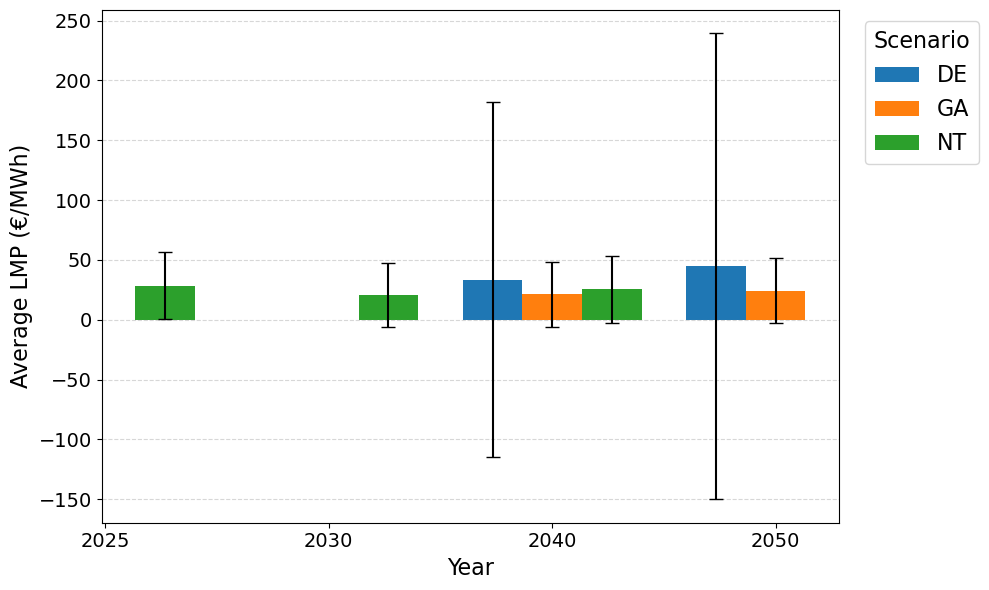

In [65]:
analytics.plot_annual_lmp_by_scenario(power_balance_duals, savefolder=dual_folder)

Average LMP by Year and Scenario


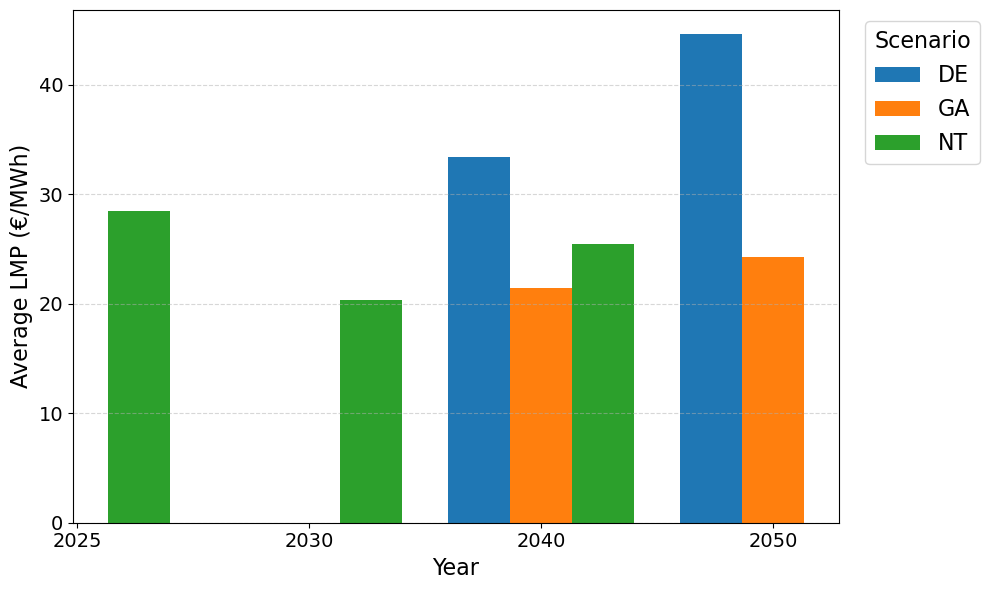

In [66]:
analytics.plot_annual_lmp_by_scenario_simple(
    power_balance_duals, savefolder=dual_folder
)

Average LMP by Year and Scenario (line chart)


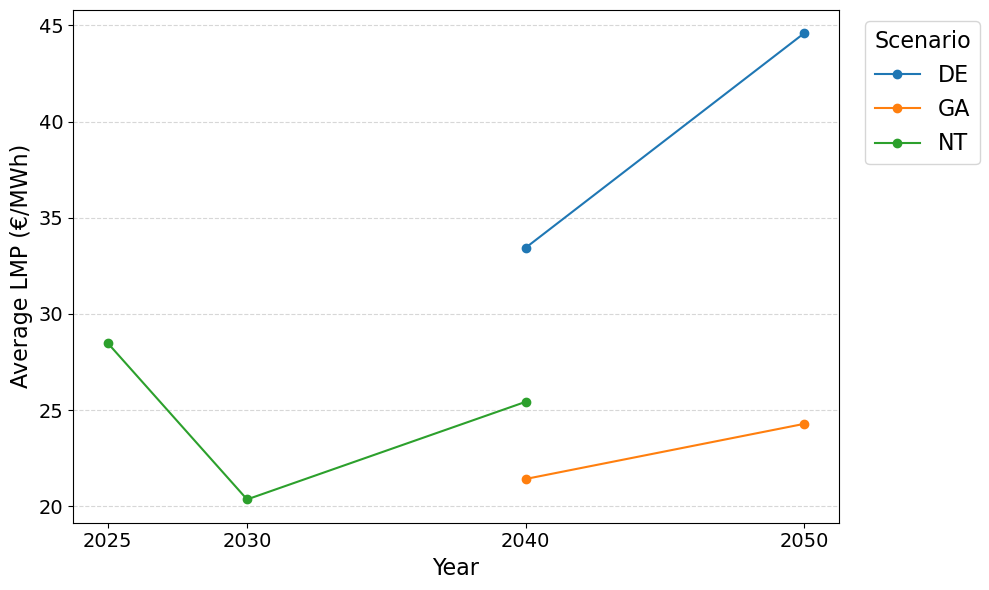

In [67]:
analytics.plot_annual_lmp_by_scenario_line(power_balance_duals, savefolder=dual_folder)

Annual Average Locational Marginal Prices by City (with markers)


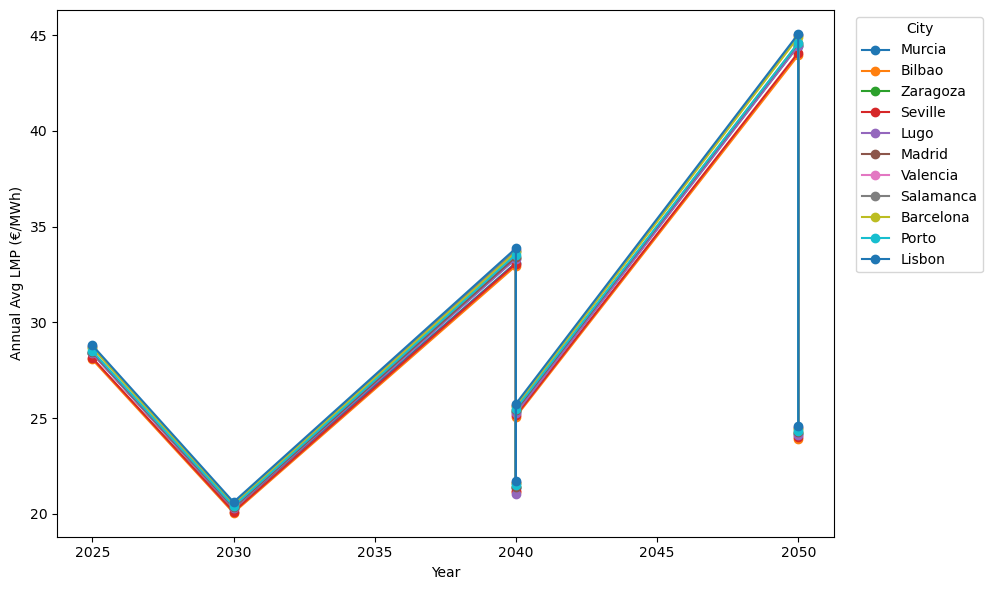

In [68]:
analytics.plot_nodal_price_evolution_with_markers(lmp_table, savefolder=dual_folder)

Annual Average Locational Marginal Prices by City (grouped bar)


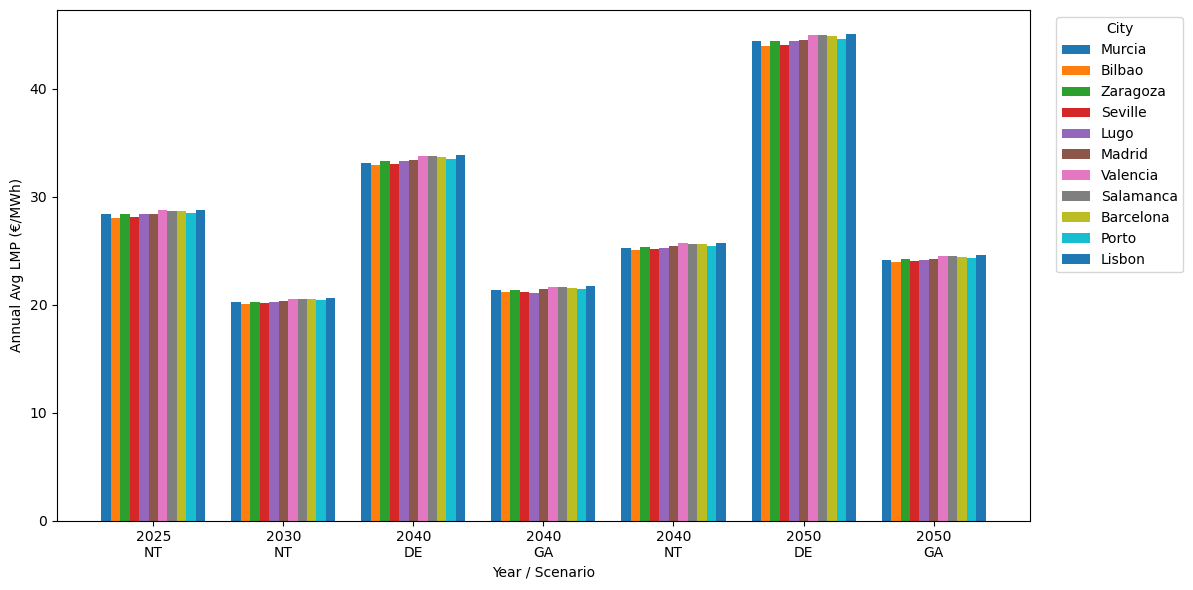

In [69]:
analytics.plot_nodal_price_grouped_bar(
    lmp_table, node_to_city=node_to_city, savefolder=dual_folder
)

In [70]:
branch_extension_duals = branch_extension_duals.rename_axis(index={"branch": "line"})
branch_extension_duals

dual_value
line year            
88   2025         0.0
     2030         0.0
     2040         0.0
     2050         0.0
89   2025         0.0
...               ...
107  2050         0.0
219  2025         0.0
     2030         0.0
     2040         0.0
     2050         0.0

[76 rows x 1 columns]

In [71]:
generators["production_cost"] = (
    generators["marginal_cost"] + generators["co2_emissions"] * CO2_price
)
generators.groupby("carrier")["production_cost"].mean().sort_values(ascending=True)

carrier
ror            0.000000
solar          0.010000
onwind         0.015000
offwind-ac     0.015000
coal          57.096970
CCGT          57.520397
Name: production_cost, dtype: float64

In [72]:
freqs = analytics.compute_lmp_bucket_frequencies(
    power_balance_duals, generators, dual_tables_folder
)


freqs

LMP Bucket Frequencies


,lower,upper,absolute,relative_percent
bucket,,,,
non-binding,-0.000100,0.000100,0,0.000000
gap_non-binding_solar,0.000100,0.009000,0,0.000000
solar,0.009000,0.011000,1606,3.103741
gap_solar_wind,0.011000,0.013500,0,0.000000
wind,0.013500,0.016500,26713,51.625309
gap_wind_thermal,0.016500,51.387273,695,1.343151
thermal,51.387273,63.272437,22170,42.845547
other,NaN,NaN,560,1.082251


LMP Bucket Absolute Frequencies


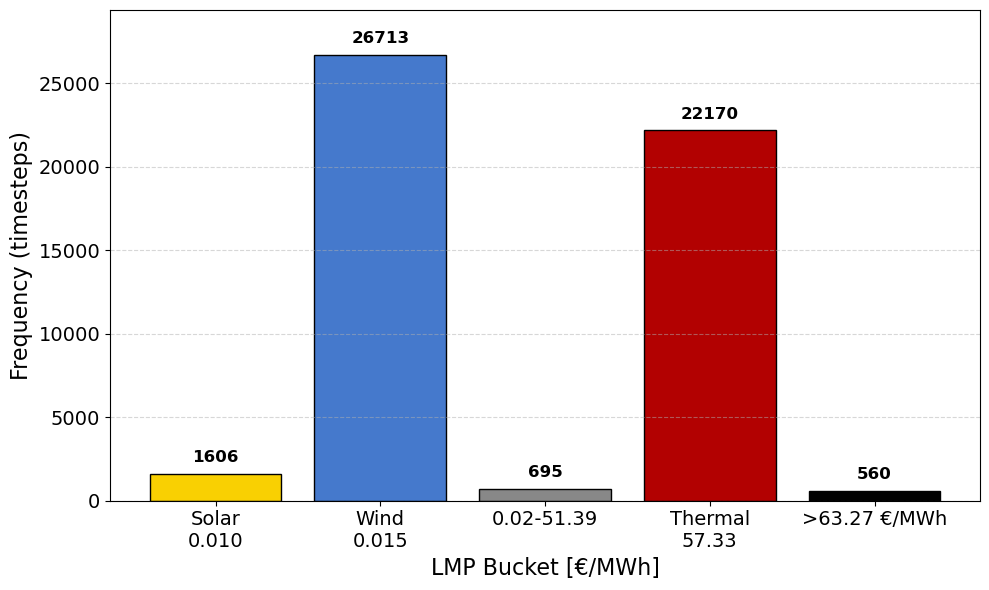

In [73]:
analytics.plot_lmp_bucket_frequencies(freqs, savefolder=dual_folder)

LMP Bucket Relative Frequencies (%)


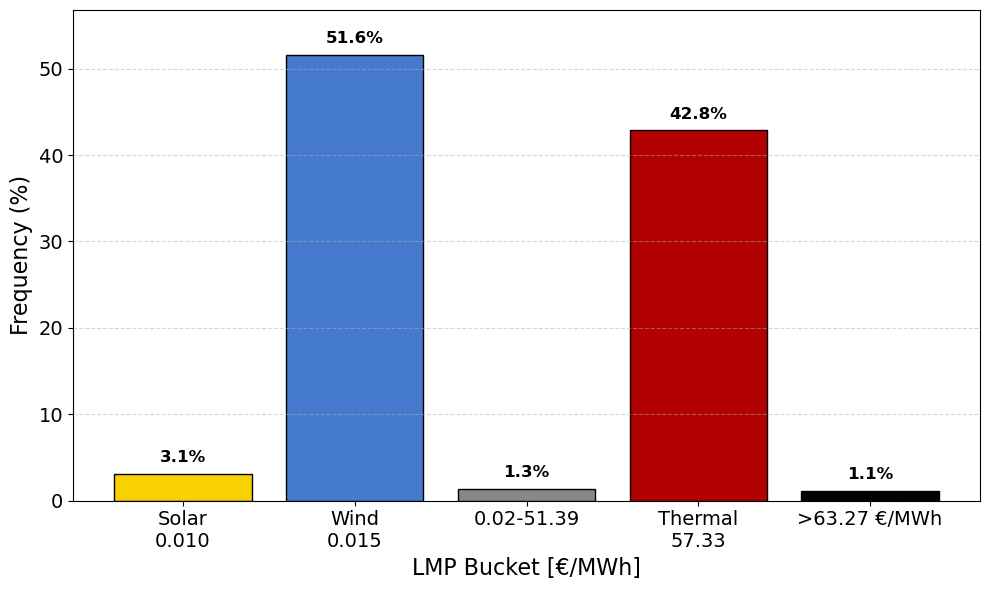

In [74]:
analytics.plot_lmp_bucket_percentages(freqs, savefolder=dual_folder)

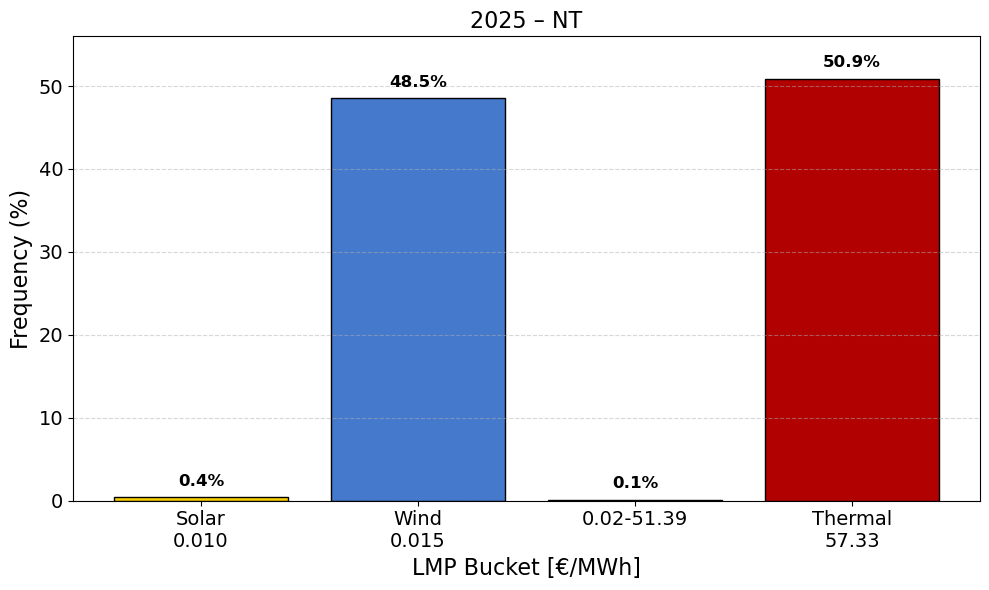

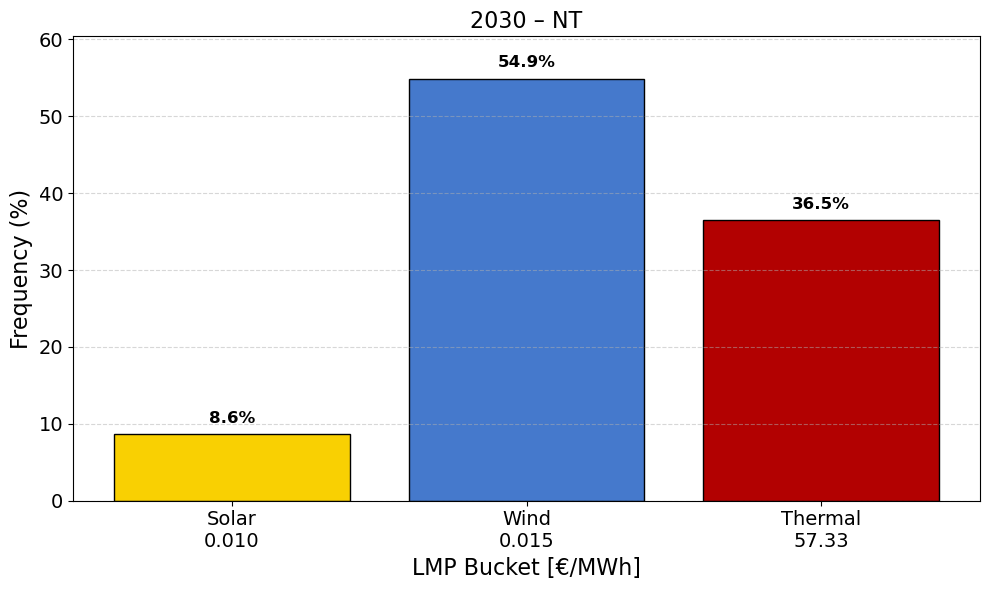

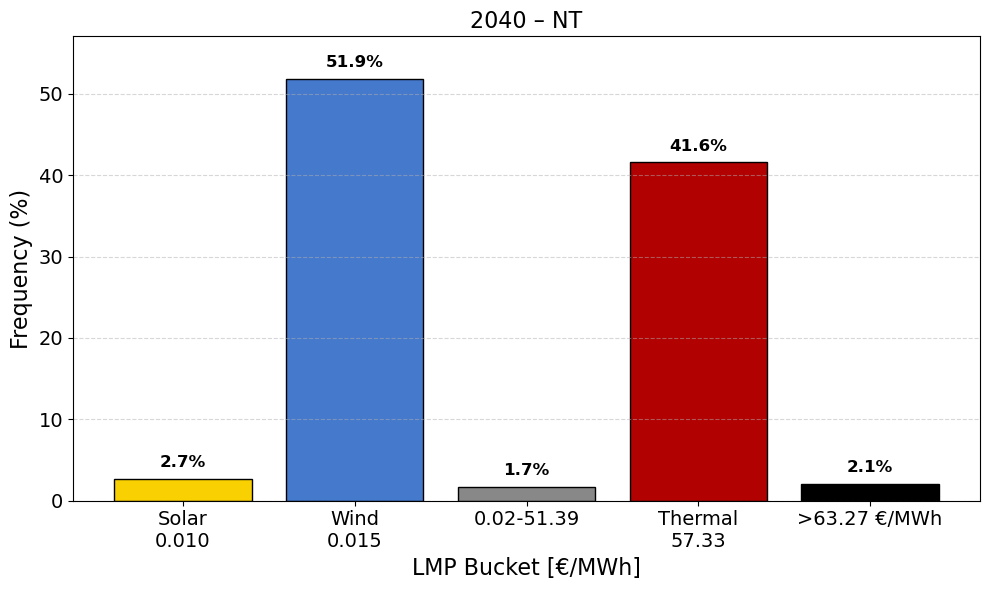

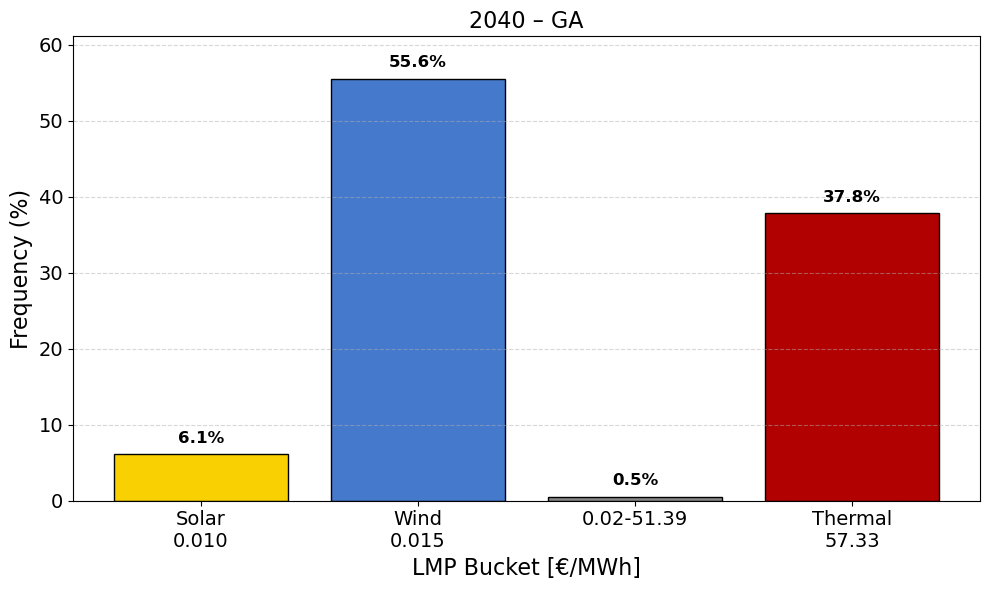

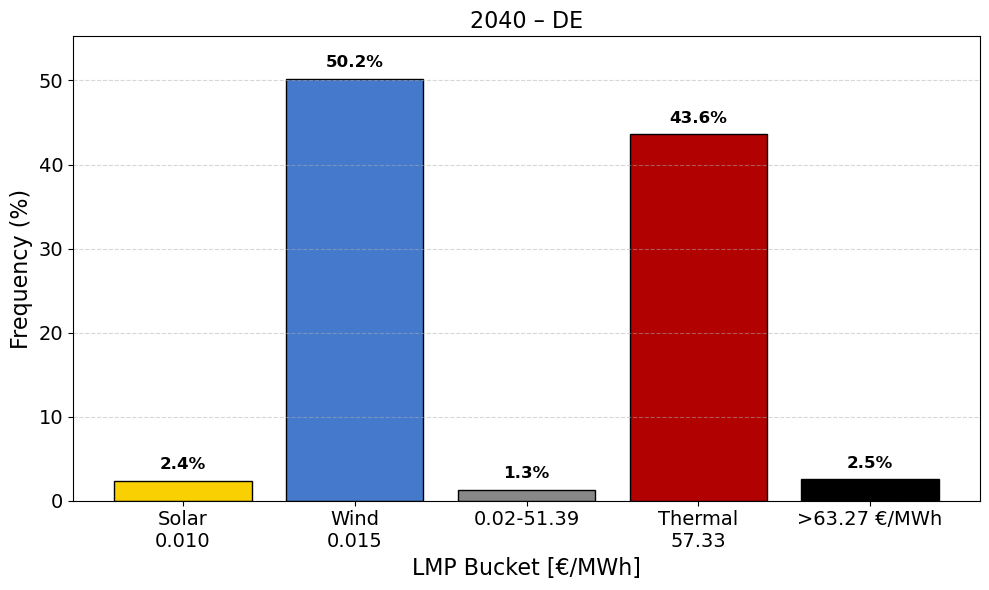

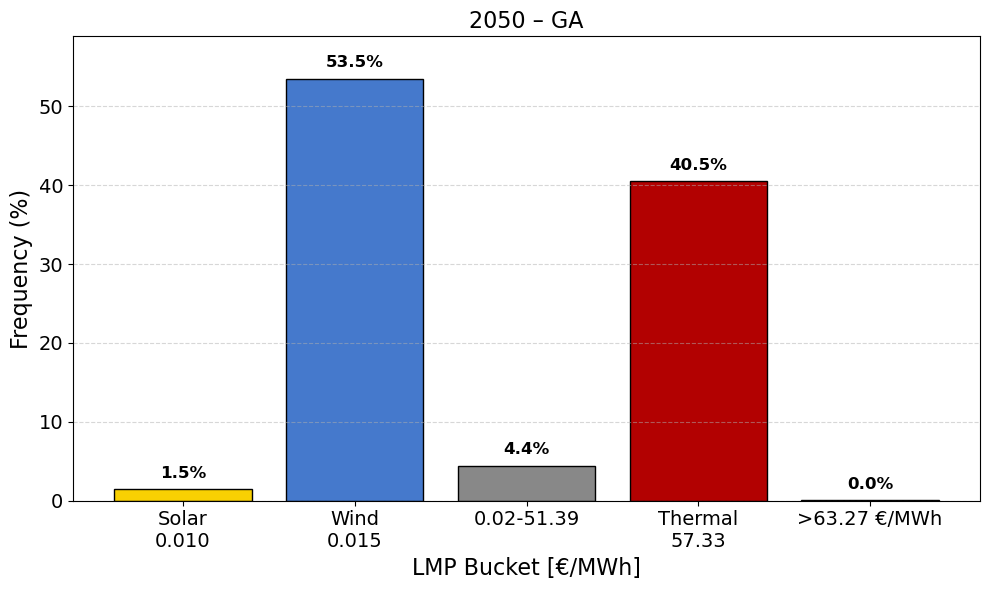

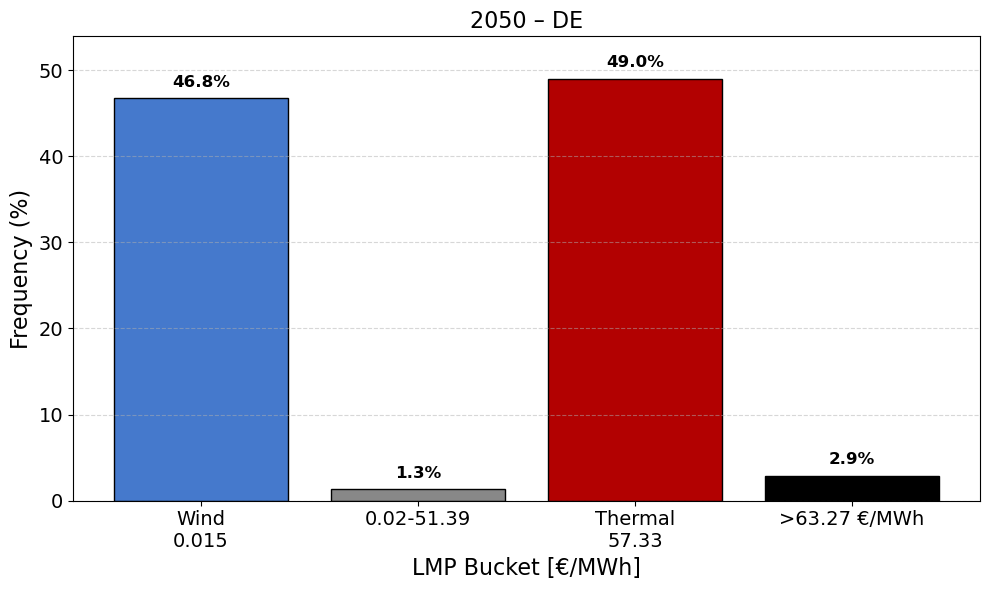

In [75]:
analytics.plot_lmp_bucket_percentages_by_year_scenario(
    power_balance_duals, freqs, savefolder=dual_folder
)

LMP event counts above 63.27 €/MWh by Year & Scenario


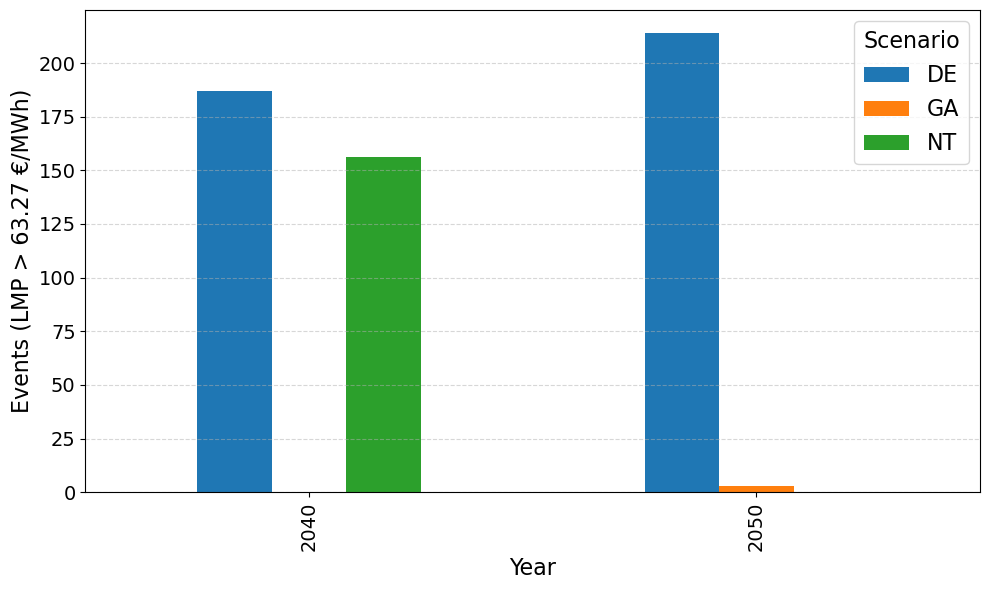

In [76]:
# determine cap from your buckets:
cap = freqs.loc[freqs.index != "other", "upper"].max()

analytics.plot_high_lmp_event_counts(power_balance_duals, cap, savefolder=dual_folder)

63.2724371519848
Distribution of LMPs > 63.27 €/MWh


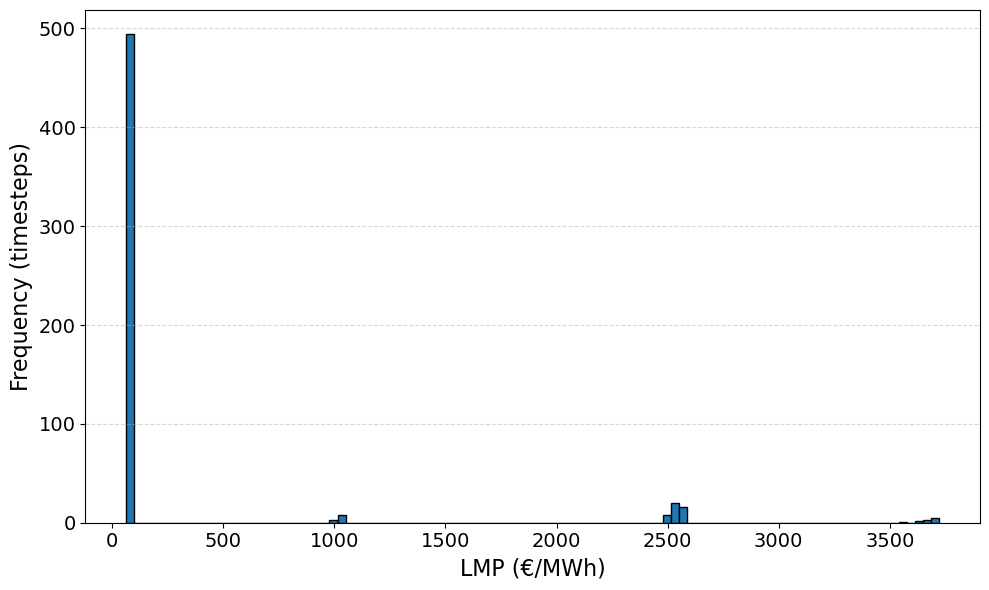

In [77]:
cap = freqs.loc[freqs.index != "other", "upper"].max()
print(cap)


analytics.plot_high_lmp_distribution(
    power_balance_duals, cap, n_bins=100, savefolder=dual_folder
)

    lower_bound  upper_bound  count  percent_of_high  percent_of_total
0        63.271       99.865    494        88.214286          0.954700
67     2514.983     2551.576     20         3.571429          0.038652
68     2551.576     2588.169     16         2.857143          0.030921
26     1014.683     1051.275      8         1.428571          0.015461
66     2478.391     2514.983      8         1.428571          0.015461
99     3685.950     3722.543      5         0.892857          0.009663
98     3649.357     3685.950      3         0.535714          0.005798
25      978.090     1014.683      3         0.535714          0.005798
97     3612.764     3649.357      2         0.357143          0.003865
95     3539.579     3576.172      1         0.178571          0.001933
Top 6 high-LMP bins by occurrence


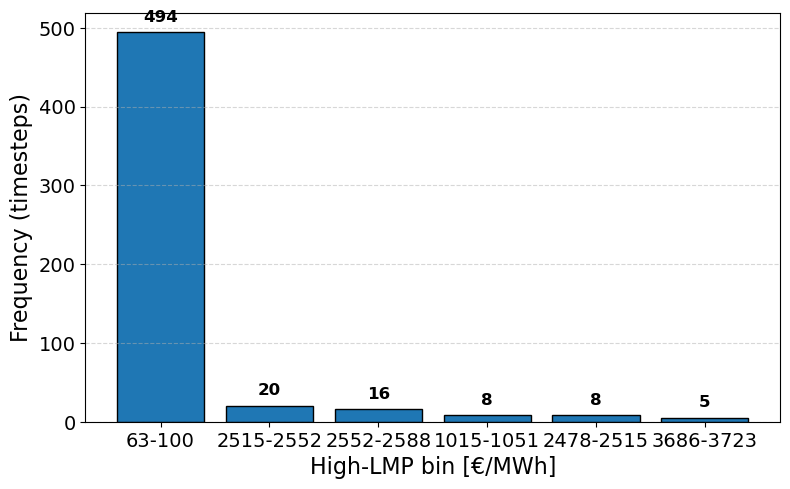

In [78]:
high_tbl = analytics.make_high_lmp_frequency_table(
    power_balance_duals, cap=cap, n_bins=100, savefolder=dual_tables_folder
)
top5 = analytics.get_top_high_lmp_buckets(
    high_tbl, top_n=10, savefolder=dual_tables_folder
)
print(top5)
analytics.plot_top_high_lmp_buckets(high_tbl, top_n=6, savefolder=dual_folder)

Detailed histogram for top high-LMP bucket (63.27–99.86 €/MWh)


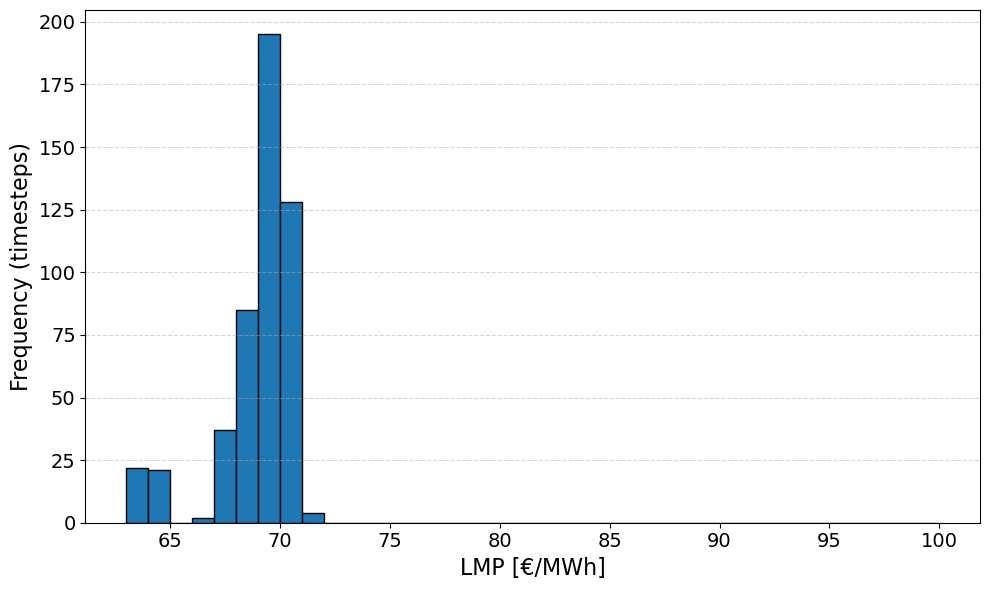

In [79]:
# Assuming you've already built `high_tbl`:
analytics.plot_top_high_bucket_detail(
    power_balance_duals, high_tbl, width=1.0, savefolder=dual_folder
)

In [80]:
power_balance_duals

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 11   0       0.015050  1.0     1.0
                         1       0.015000  1.0     1.0
                         2       0.014951  1.0     1.0
                         3       0.014951  1.0     1.0
                         4       0.014909  1.0     1.0
...                                   ...  ...     ...
PT1 1 DE       2050 52   163    55.892841  0.5     2.0
                         164    55.892841  0.5     2.0
                         165    55.892841  0.5     2.0
                         166    55.892841  0.5     2.0
                         167    55.892841  0.5     2.0

[51744 rows x 3 columns]

               count_total  count_bucket  percent_bucket_of_total
year scenario                                                    
2025 NT               7392            10                 0.135281
2030 NT               7392             0                 0.000000
2040 DE               7392            95                 1.285173
     GA               7392            38                 0.514069
     NT               7392           127                 1.718074
2050 DE               7392            99                 1.339286
     GA               7392           326                 4.410173
Distribution of LMPs in bucket 'gap_wind_thermal'


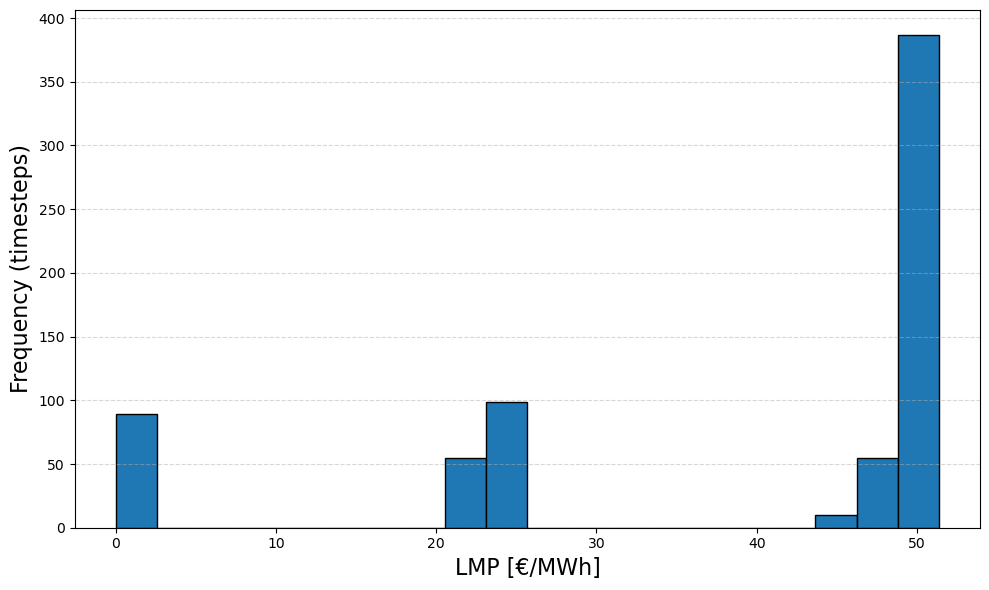

In [81]:
gap_subset = analytics.extract_duals_in_lmp_bucket(
    power_balance_duals, freqs, "gap_wind_thermal"
)
gap_summary = analytics.summarize_gap_duals_by_year_scenario(
    gap_subset, power_balance_duals, savefolder=dual_tables_folder
)
print(gap_summary)
analytics.plot_gap_lmp_distribution(
    gap_subset, "gap_wind_thermal", savefolder=dual_folder
)

LMP ≥ 70 €/MWh: count = 198 timesteps


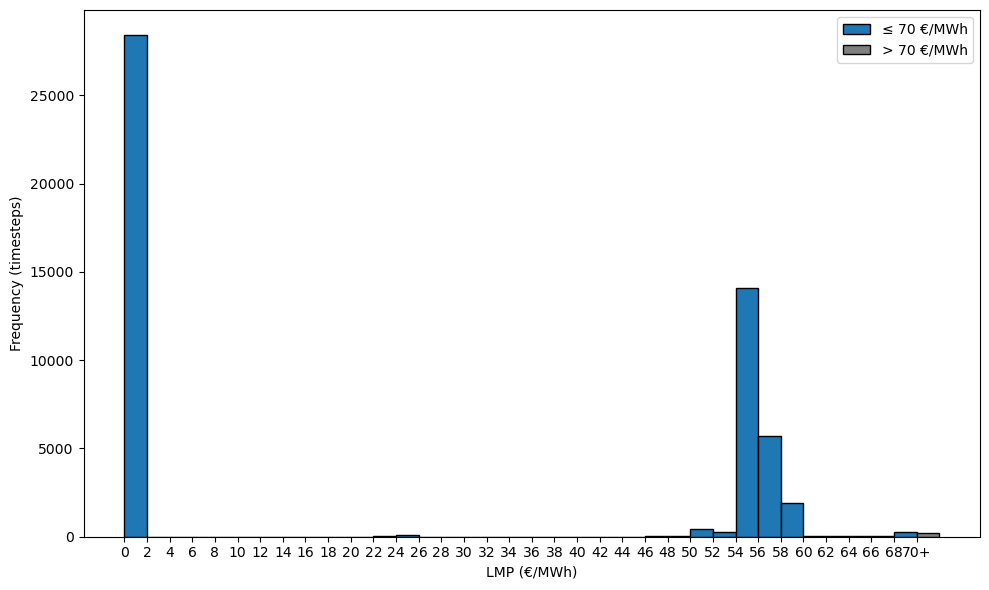

In [82]:
analytics.plot_lmp_histogram_70plus(
    power_balance_duals, cap=70, bin_width=2.0, savefolder=dual_folder
)

In [83]:
freq_table = analytics.make_lmp_frequency_table(
    power_balance_duals, bin_width=1.0, cap=70, savefolder=dual_tables_folder
)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    sorted_freq_table = freq_table.sort_values(by="count", ascending=False)
    display(sorted_freq_table)

,lower_bound,upper_bound,count,percent,count_2025,count_2030,count_2040,count_2050
0,0.0,1.0,28408,54.901051,3619,4697,12523,7569
55,55.0,56.0,9597,18.547078,1840,1196,3847,2714
54,54.0,55.0,4482,8.661874,747,638,1829,1268
56,56.0,57.0,3737,7.222093,699,386,1527,1125
57,57.0,58.0,1967,3.801407,284,246,842,595
58,58.0,59.0,1273,2.460189,141,139,575,418
59,59.0,60.0,624,1.205937,43,56,265,260
53,53.0,54.0,255,0.492811,8,34,145,68
50,50.0,51.0,250,0.483148,7,0,156,87
51,51.0,52.0,204,0.394249,3,0,69,132


In [84]:
generators["production_cost"].groupby(generators["carrier"]).mean().sort_values(
    ascending=True
)

carrier
ror            0.000000
solar          0.010000
onwind         0.015000
offwind-ac     0.015000
coal          57.096970
CCGT          57.520397
Name: production_cost, dtype: float64

In [ ]:
# plot_top_10_dual_intervals(
#     power_balance_duals, sorted_freq_table, n_bins=10, savefolder=dual_folder
# )
# create_top_10_dual_intervals_tables(
#     power_balance_duals, freq_table, n_bins=10, savefolder=dual_tables_folder
# )

In [86]:
average_duals = power_balance_duals.groupby("year")["dual_value"].mean()
average_duals

year
2025    28.481108
2030    20.358291
2040    26.762731
2050    34.438788
Name: dual_value, dtype: float64

In [92]:
summary_by_carrier = analytics.summarise_extension_status_by_carrier(
    generators, savefolder=generators_save_table_folder
)


summary_by_carrier

Extension status by carrier


extension_status  not extended  partly extended  fully extended
year carrier                                                   
2025 CCGT                   10                1               0
     coal                    5                0               0
     offwind-ac              7                0               2
     onwind                  5                0               6
     ror                     2                0               2
     solar                   0                0              11
2030 CCGT                   11                0               0
     coal                    5                0               0
     offwind-ac              8                0               1
     onwind                  9                0               2
     ror                     3                1               0
     solar                   1                1               9
2040 CCGT                   11                0               0
     coal                    5                0               0
     offwind-ac              9                0               0
     onwind                 10                0               1
     ror                     4                0               0
     solar                  10                0               1
2050 CCGT                   11                0               0
     coal                    5                0               0
     offwind-ac              9                0               0
     onwind                 11                0               0
     ror                     4                0               0
     solar                  11                0               0

In [88]:
# Usage example:
summary_table = analytics.summarize_dual_nonzero_counts(
    dual_variables, dual_tables_folder
)
summary_table

,total_duals,nonzero_duals,percent_nonzero
dual,,,
battery_charge_new_max_duals,51744,1138,2.199289
battery_charge_old_duals,0,0,0.000000
battery_discharge_new_max_duals,51744,675,1.304499
battery_discharge_old_duals,0,0,0.000000
branch_extension_duals,76,1,1.315789
branch_flow_new_duals_max,89376,9639,10.784774
branch_flow_new_duals_min,89376,34542,38.647959
branch_flow_old_duals_max,89376,9621,10.764635
branch_flow_old_duals_min,89376,34524,38.627820


In [89]:
summary = analytics.summarize_duals_by_year_scenario(
    dual_variables, savefolder=dual_tables_folder
)

with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.width", None
):

    display(summary)

total_duals  nonzero_duals  \
dual                            year scenario                               
battery_charge_new_max_duals    2025 NT               7392             48   
                                2030 NT               7392            326   
                                2040 DE               7392            169   
                                     GA               7392            210   
                                     NT               7392            252   
                                2050 DE               7392             41   
                                     GA               7392             92   
battery_discharge_new_max_duals 2025 NT               7392            143   
                                2030 NT               7392             70   
                                2040 DE               7392            133   
                                     GA               7392            111   
                                     NT               7392            119   
                                2050 DE               7392             51   
                                     GA               7392             48   
branch_extension_duals          2025 All                19              1   
                                2030 All                19              0   
                                2040 All                19              0   
                                2050 All                19              0   
branch_flow_new_duals_max       2025 NT              12768           1254   
                                2030 NT              12768           1391   
                                2040 DE              12768           1400   
                                     GA              12768           1423   
                                     NT              12768           1407   
                                2050 DE              12768           1389   
                                     GA              12768           1375   
branch_flow_new_duals_min       2025 NT              12768           5035   
                                2030 NT              12768           4942   
                                2040 DE              12768           4917   
                                     GA              12768           4915   
                                     NT              12768           4900   
                                2050 DE              12768           4944   
                                     GA              12768           4889   
branch_flow_old_duals_max       2025 NT              12768           1251   
                                2030 NT              12768           1390   
                                2040 DE              12768           1399   
                                     GA              12768           1419   
                                     NT              12768           1404   
                                2050 DE              12768           1384   
                                     GA              12768           1374   
branch_flow_old_duals_min       2025 NT              12768           5034   
                                2030 NT              12768           4941   
                                2040 DE              12768           4915   
                                     GA              12768           4912   
                                     NT              12768           4900   
                                2050 DE              12768           4934   
                                     GA              12768           4888   
emissions_duals                 2025 NT                  1              0   
                                2030 NT                  1              0   
                                2040 DE                  1              0   
                                     GA                  1              0   
                                     NT    

In [90]:
nz = analytics.list_nonzero_gen_extension_duals(
    gen_extension_duals, savefolder=dual_tables_folder
)

nz

dual_value
year generator                      
2025 ES1 4 offwind-ac -121770.343909
     ES1 4 onwind      -98718.656325
     PT1 1 ror         -87410.141007
     PT1 0 ror         -83276.254010
     ES1 2 onwind      -59288.565619
     ES1 6 solar       -32739.260157
     ES1 2 solar       -30759.042326
     ES1 5 solar       -30618.691578
     PT1 0 offwind-ac  -30030.667353
     ES1 8 solar       -29308.392096
     ES1 3 solar       -27984.260188
     PT1 1 solar       -27776.686955
     ES1 0 solar       -24506.907997
     ES1 7 solar       -21057.595760
     PT1 0 solar       -16649.272941
     ES1 4 solar       -15671.567358
     ES1 1 onwind      -14807.143484
     ES1 1 solar       -12163.542246
     ES1 8 onwind       -9472.635869
     PT1 1 onwind       -7637.608236
     ES1 6 onwind       -3830.880814
2030 ES1 4 onwind      -38080.445800
     ES1 4 offwind-ac  -29615.620184
     ES1 2 onwind      -13115.141473
     ES1 6 solar       -10419.247821
     ES1 2 solar        -9167.118694
     ES1 5 solar        -9059.249041
     ES1 8 solar        -7938.905830
     PT1 1 solar        -7611.556972
     ES1 3 solar        -6961.816734
     ES1 0 solar        -4600.059941
     ES1 7 solar        -2723.531244
     PT1 0 solar         -462.775094
2040 ES1 4 onwind       -2027.364655
     ES1 6 solar         -404.924562

In [91]:
generators.groupby("carrier")["capital_cost"].mean()

carrier
CCGT           99027.729293
coal          349976.553630
offwind-ac    184196.306769
onwind         96085.888020
ror           299140.224929
solar          35602.071244
Name: capital_cost, dtype: float64